<a href="https://colab.research.google.com/github/whateveri/models/blob/2d_PPDM_MINIST/2Ddiffusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

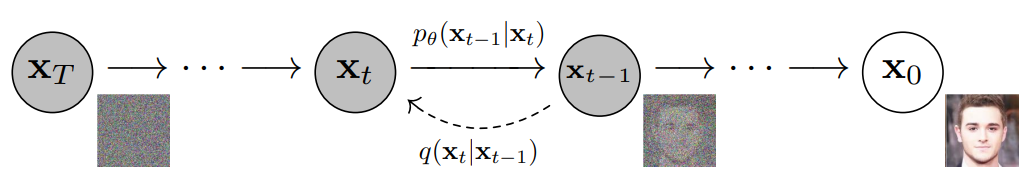

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader,Dataset
import math,random
from matplotlib import pyplot as plt
from matplotlib import animation as animation

device="cuda" if torch.cuda.is_available() else "cpu"


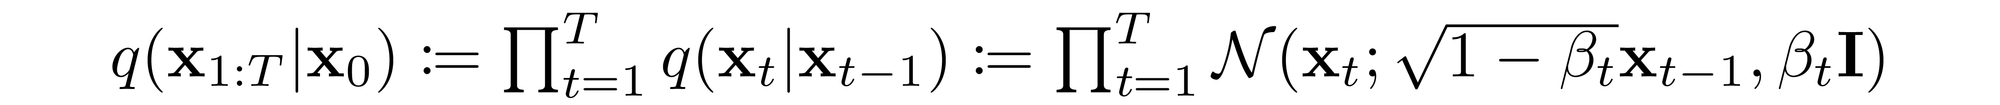

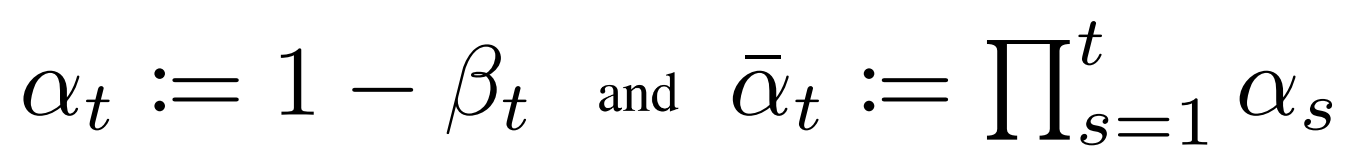

In [2]:
#beta schedule for forward process(linear variance schedule)

def linear_beta_schedule(timesteps,beta_start=1e-4, beta_end=2e-2):
    return torch.linspace(beta_start,beta_end,timesteps)

T=400
betas=linear_beta_schedule(T).to(device)
alphas=1.-betas
alphas_cumprod=torch.cumprod(alphas,dim=0)



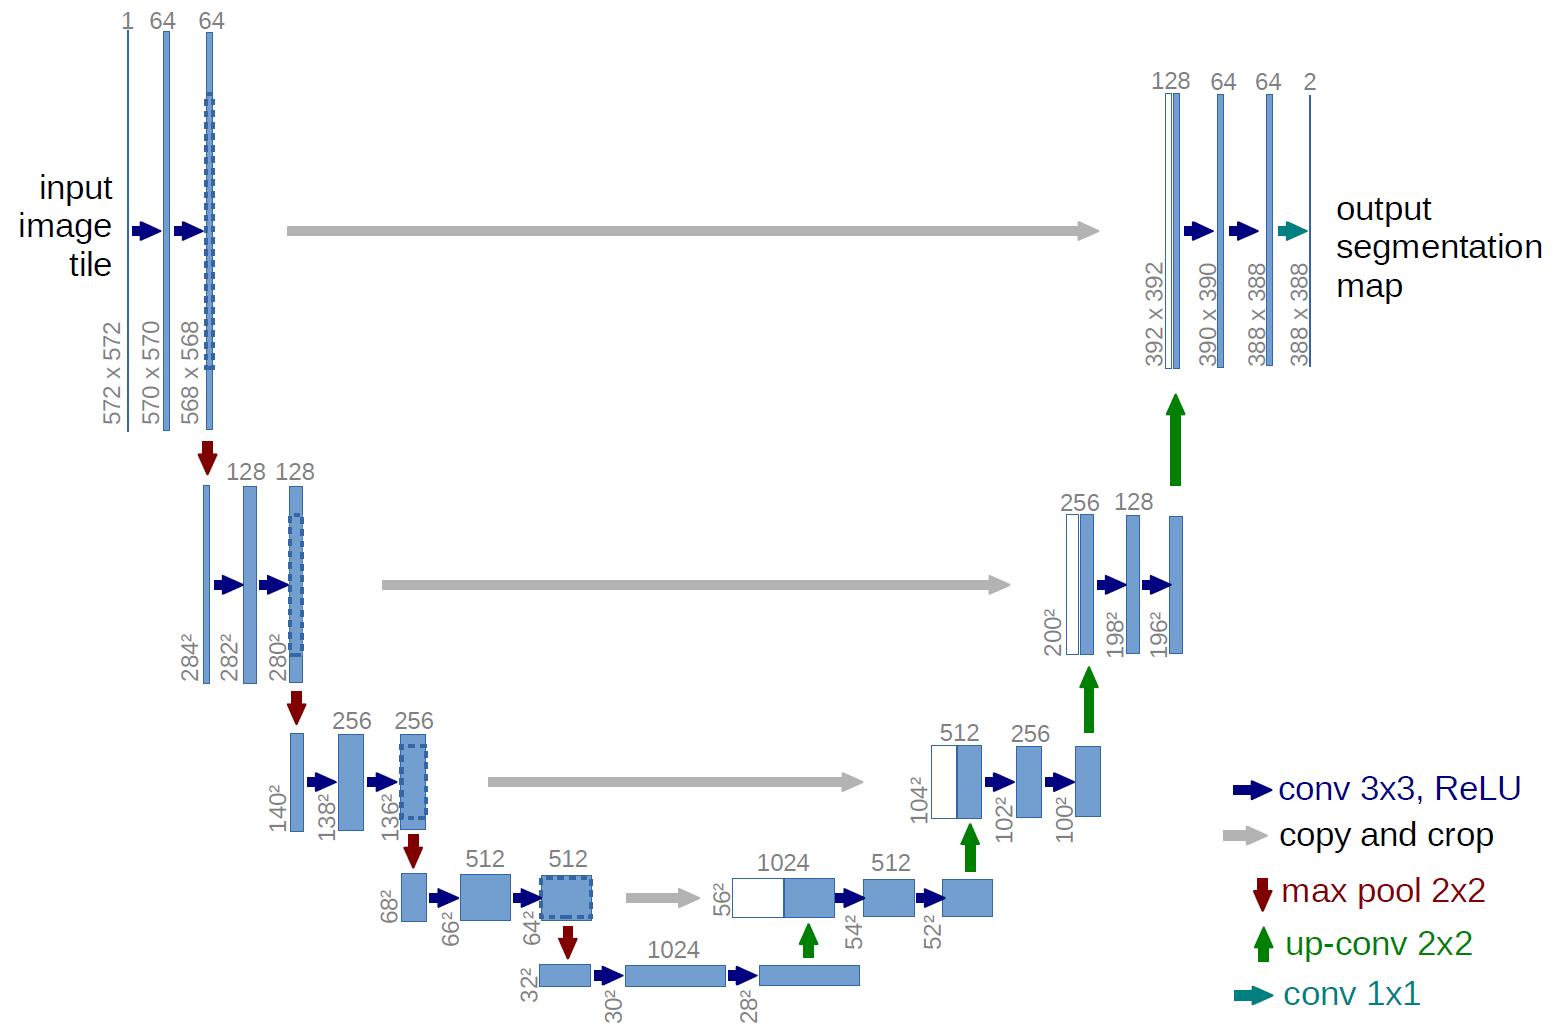

In [3]:
#time embedding
class SinusodialPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim=dim

    def forward(self,pos):
        device=pos.device
        half=self.dim //2
        freq=torch.exp(-math.log(10000) * torch.arange(0,half,device=device).float() / half  )
        args=pos.float().unsqueeze(1)* freq.unsqueeze(0)
        emb=torch.cat([torch.sin(args),torch.cos(args)],dim=-1)
        return emb

#simple UNet(PixelCNN++ as backbone, a UNet based on Wide ResNet)




#resBlock


def rearrange_dims(tensor:torch.tensor):
    if len(tensor.shape)==2:
        return tensor[:,:,None]

    elif len(tensor.shape)==3:
        return tensor[:,:,None,None]
    elif len(tensor.shape)==4:
        return tensor[:,:,0,:]
    else:
        raise ValueError(f'error:{len(tensor.shape)}should be 2 or 3 or4')


#conv2DBlock

class conv2DBlock(nn.Module):

    def __init__(self, in_size, out_size, kernel_size, n_group,padding):
        super().__init__()
        self.conv2d=nn.Conv2d(in_size,out_size,kernel_size=kernel_size,padding=padding)

        n_group=min(in_size,1)
        self.norm=nn.GroupNorm(num_groups=n_group,num_channels=in_size)

        self.activ=nn.SiLU()

    def forward(self,x):
        out=self.norm(x)
        out=self.activ(out)
        out=self.conv2d(out)
        return out







class resBlock(nn.Module):
    def __init__(self, in_size,out_size,time_dim) :
        super().__init__()


        self.convBlock_in=conv2DBlock(in_size,out_size,kernel_size=3,n_group=8,padding=1)
        self.convBlock_out=conv2DBlock(out_size,out_size,kernel_size=3,n_group=8 ,padding=1)


        self.time_mlp=nn.Linear(time_dim,out_size)

        self.residual_conv=(
            nn.Conv2d(in_size,out_size,kernel_size=1) if in_size != out_size else nn.Identity()
        )


    def forward(self,x,t_emb):
        """
        x:(B,H=input_size,W)
        time_emb:(B,time_dim)
        """

        t_emb=F.silu(t_emb)

        time_emb=self.time_mlp(t_emb)[:,:,None,None]



        h=self.convBlock_in(x)

        print(f'h shape:{h.shape}, time_emb shape:{time_emb.shape}')
        ##h=h+ rearrange_dims(time_emb)
        h=h + time_emb


        h=self.convBlock_out(h)

        x=self.residual_conv(x)

        return h+x



class SmallUNet(nn.Module):
    def __init__(self, in_size=1, base=64, time_dim=512): #in_channel size=1:gray image
        super().__init__()
        self.time_embed=nn.Sequential(SinusodialPosEmb(time_dim),nn.Linear(time_dim,time_dim),nn.SiLU())

        #downSampling

        self.resBlock1=resBlock(in_size=in_size,out_size=base,time_dim=time_dim)

        self.down1=nn.Conv2d(base,base*2,4,stride=2,padding=1)

        self.resBlock2=resBlock(in_size=base*2,out_size=base*2,time_dim=time_dim)

        self.down2=nn.Conv2d(base*2,base*4,kernel_size=4,stride=2,padding=1)

        self.resBlock3=resBlock(in_size=base*4,out_size=base*4,time_dim=time_dim)

        #middle
        self.mid=resBlock(in_size=base*4,out_size=base*4,time_dim=time_dim)

        # upSampling

        self.up1=nn.ConvTranspose2d(base*4,base*2,kernel_size=4,stride=2,padding=1)

        self.resBlock4=resBlock(in_size=4*base,out_size=base*2,time_dim=time_dim)

        self.up2=nn.ConvTranspose2d(base*2,base,kernel_size=4,stride=2,padding=1)

        self.resBlock5=resBlock(in_size=base*2,out_size=base,time_dim=time_dim)

        #64channels -> input channels,size unchanged
        self.out=nn.Sequential(nn.GroupNorm(8,base), nn.SiLU(), nn.Conv2d(base,in_size,kernel_size=3,padding=1))


    def forward(self,x,t):
        temb=self.time_embed(t)
        h1=self.resBlock1(x,temb)
        d1=self.down1(h1)
        h2=self.resBlock2(d1,temb)
        d2=self.down2(h2)
        h3=self.resBlock3(d2,temb)
        h_mid=self.mid(h3,temb)
        u1=self.up1(h_mid)
        #copy and crop
        cat1=torch.cat([u1,h2],dim=1)

        h4=self.resBlock4(cat1,temb)
        u2=self.up2(h4)
        cat2=torch.cat([u2,h1],dim=1)
        h5=self.resBlock5(cat2,temb)
        out=self.out(h5)

        return out





In [4]:
#dataset (MINIST)

from torchvision import transforms,datasets
from torch.utils.data import DataLoader

import os

transform=transforms.Compose([transforms.ToTensor()])

ds=datasets.MNIST(os.path.join(os.getcwd(),"MINIST"),download=True,train=True,transform=transform)

loader=DataLoader(ds,batch_size=64,shuffle=True,pin_memory=True)

model=SmallUNet(in_size=1,base=64,time_dim=512).to(device=device)

opt=torch.optim.Adam(model.parameters(),lr=2e-4)



100%|██████████| 9.91M/9.91M [00:00<00:00, 19.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 501kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.68MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.7MB/s]


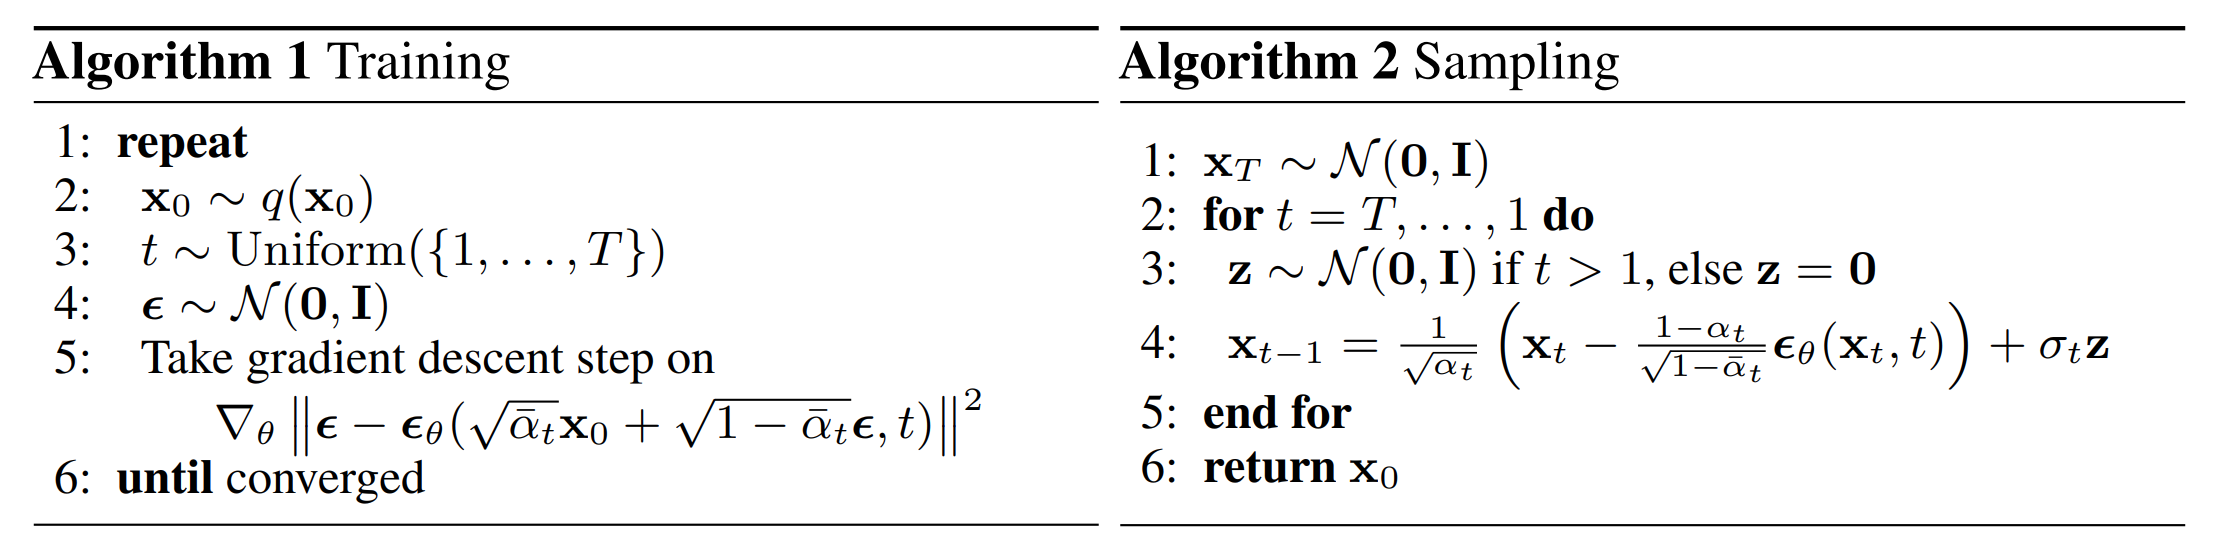

In [5]:
#q_sample helpler (Training algorithm)
def q_sampler(x0,t,eps=None): #get sampled x_t
    if eps is None:
        eps=torch.randn_like(x0)

    alpha_hat=alphas_cumprod[t].view(-1,1,1,1) #丌t(1-beta_t) size:[1]->[1,1,1,1]
    result=torch.sqrt(alpha_hat) * x0 + torch.sqrt(1-alpha_hat)*eps
    return result


In [6]:
#training

epochs=10

for epoch in range(epochs):
    model.train()

    for imgs,_ in loader:
        imgs=imgs.to(device)
        batch_size=imgs.size(0)
        t=torch.randint(0,T,size=(batch_size,),device=device).long()
        eps=torch.randn_like(imgs)
        x_t=q_sampler(imgs,t,eps)
        print(f"x_t device:{x_t.device}, t device:{t.device}")
        pred=model(x_t,t)
        loss=F.mse_loss(pred,eps)
        opt.zero_grad()
        loss.backward()
        opt.step()
    print(f'epoch {epoch}:loss:{loss.item()}')




流式输出内容被截断，只能显示最后 5000 行内容。
h shape:torch.Size([64, 64, 28, 28]), time_emb shape:torch.Size([64, 64, 1, 1])
x_t device:cuda:0, t device:cuda:0
h shape:torch.Size([64, 64, 28, 28]), time_emb shape:torch.Size([64, 64, 1, 1])
h shape:torch.Size([64, 128, 14, 14]), time_emb shape:torch.Size([64, 128, 1, 1])
h shape:torch.Size([64, 256, 7, 7]), time_emb shape:torch.Size([64, 256, 1, 1])
h shape:torch.Size([64, 256, 7, 7]), time_emb shape:torch.Size([64, 256, 1, 1])
h shape:torch.Size([64, 128, 14, 14]), time_emb shape:torch.Size([64, 128, 1, 1])
h shape:torch.Size([64, 64, 28, 28]), time_emb shape:torch.Size([64, 64, 1, 1])
x_t device:cuda:0, t device:cuda:0
h shape:torch.Size([64, 64, 28, 28]), time_emb shape:torch.Size([64, 64, 1, 1])
h shape:torch.Size([64, 128, 14, 14]), time_emb shape:torch.Size([64, 128, 1, 1])
h shape:torch.Size([64, 256, 7, 7]), time_emb shape:torch.Size([64, 256, 1, 1])
h shape:torch.Size([64, 256, 7, 7]), time_emb shape:torch.Size([64, 256, 1, 1])
h shape:torch.Siz

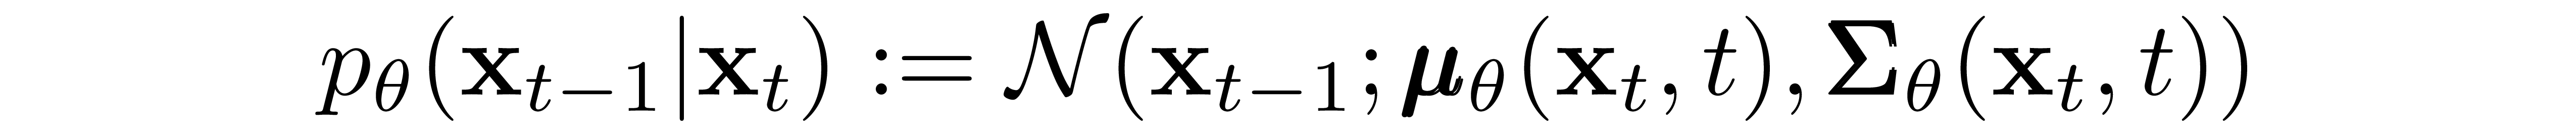

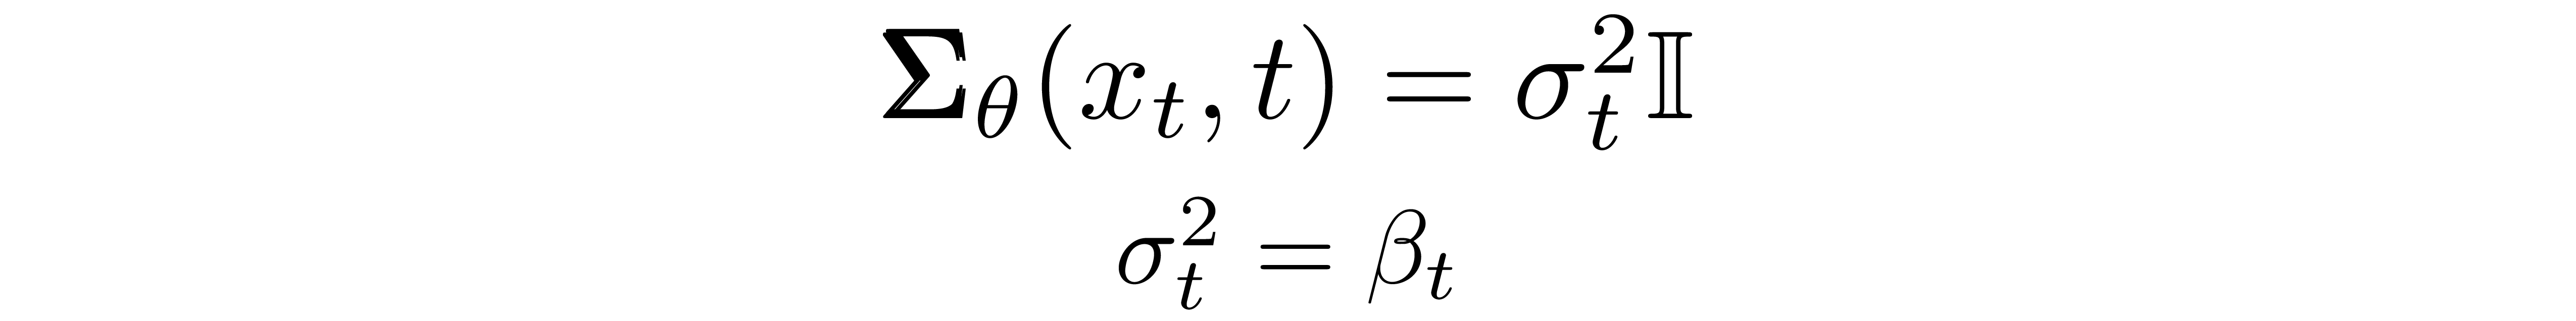

In [7]:
from torchvision.utils import make_grid


#Sampling Algorithm

sample_batch_size=4

def sampling_and_trace(model,img_shape,n):
    img_steps=[]

    x=torch.randn(n,*img_shape,device=device)
    for i in reversed(range(T)):
        t=torch.full((n,),i,device=device,dtype=torch.long)
        pred_eps=model(x,t)
        beta_t=betas[i]
        alpha_t=alphas[i]
        alpha_hat_t=alphas_cumprod[i]
        coeff1=1./torch.sqrt(alpha_t)
        coeff2=beta_t/(torch.sqrt(1-alpha_hat_t))
        x_mu= coeff1 *(x- coeff2 * pred_eps)
        if i>0:
            sigma=torch.sqrt(beta_t)
            x=x_mu + sigma * torch.randn_like(x)
        else:
            x=x_mu

        img_steps.append(x.clamp(-1,1).detach().cpu())

    return img_steps


#visualize each step
def show_step(images,nrow=sample_batch_size):
    #gride shape(B,H,W)
    grid=make_grid(images,nrow=nrow,normalize=True,value_range=(-1,1))
    plt.imshow(grid.permute(1,2,0).squeeze(),cmap='gray')
    plt.axis('off')
    plt.show()




h shape:torch.Size([4, 64, 28, 28]), time_emb shape:torch.Size([4, 64, 1, 1])
h shape:torch.Size([4, 128, 14, 14]), time_emb shape:torch.Size([4, 128, 1, 1])
h shape:torch.Size([4, 256, 7, 7]), time_emb shape:torch.Size([4, 256, 1, 1])
h shape:torch.Size([4, 256, 7, 7]), time_emb shape:torch.Size([4, 256, 1, 1])
h shape:torch.Size([4, 128, 14, 14]), time_emb shape:torch.Size([4, 128, 1, 1])
h shape:torch.Size([4, 64, 28, 28]), time_emb shape:torch.Size([4, 64, 1, 1])
h shape:torch.Size([4, 64, 28, 28]), time_emb shape:torch.Size([4, 64, 1, 1])
h shape:torch.Size([4, 128, 14, 14]), time_emb shape:torch.Size([4, 128, 1, 1])
h shape:torch.Size([4, 256, 7, 7]), time_emb shape:torch.Size([4, 256, 1, 1])
h shape:torch.Size([4, 256, 7, 7]), time_emb shape:torch.Size([4, 256, 1, 1])
h shape:torch.Size([4, 128, 14, 14]), time_emb shape:torch.Size([4, 128, 1, 1])
h shape:torch.Size([4, 64, 28, 28]), time_emb shape:torch.Size([4, 64, 1, 1])
h shape:torch.Size([4, 64, 28, 28]), time_emb shape:torc

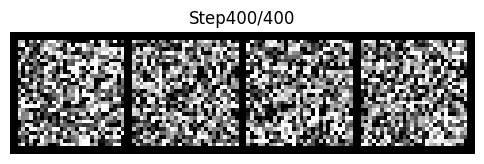

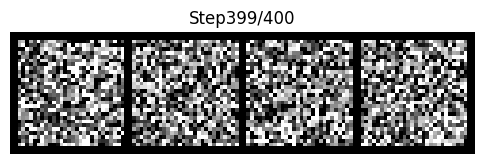

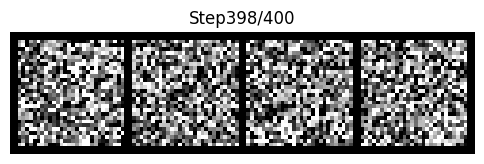

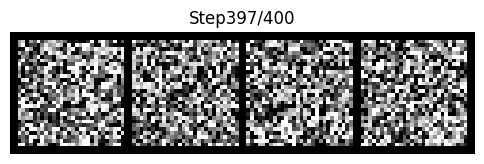

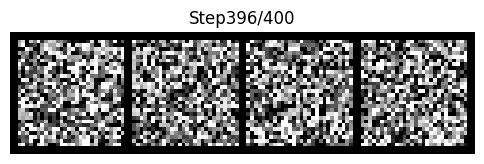

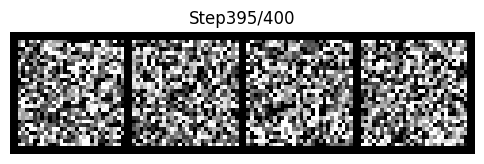

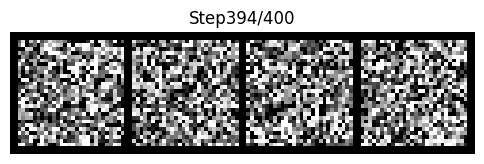

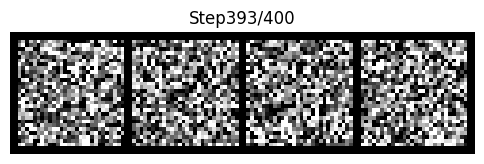

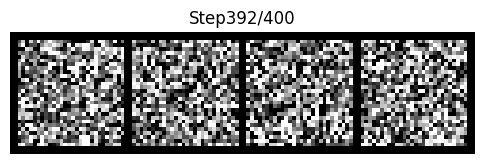

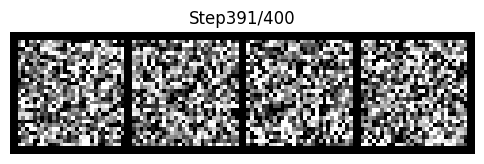

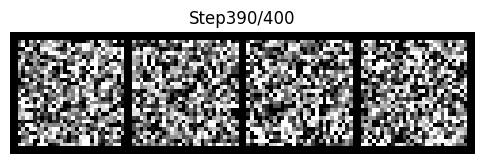

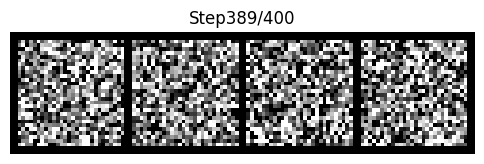

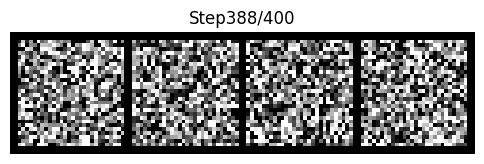

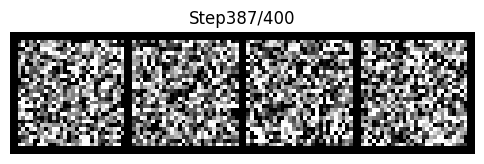

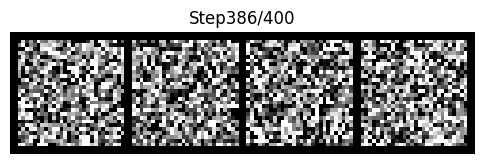

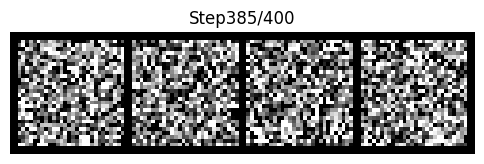

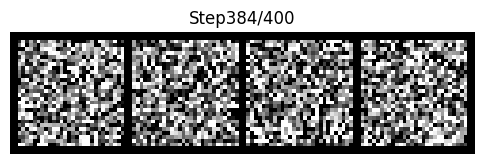

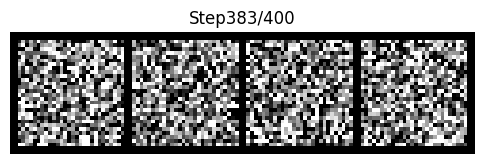

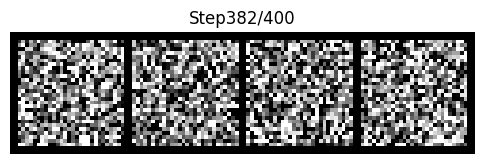

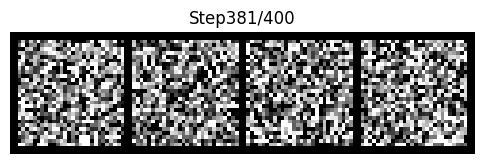

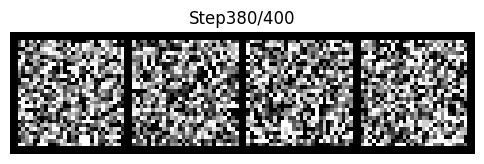

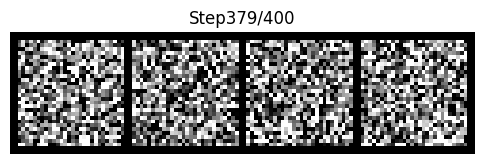

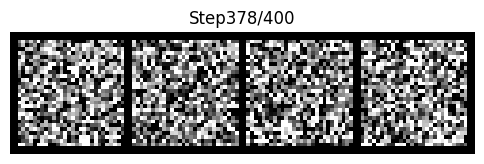

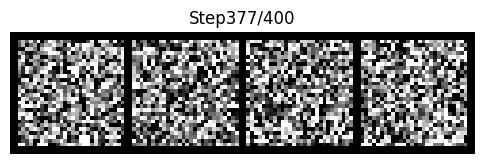

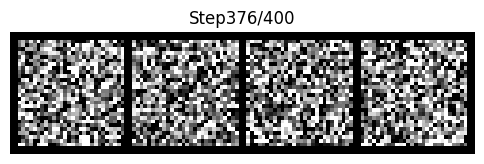

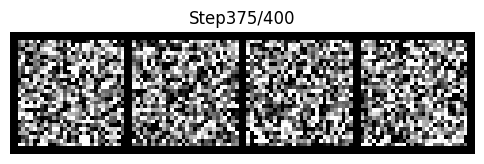

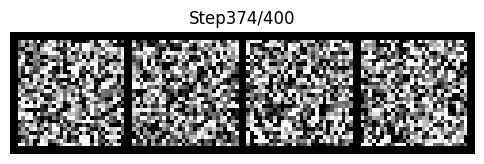

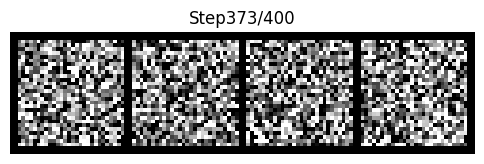

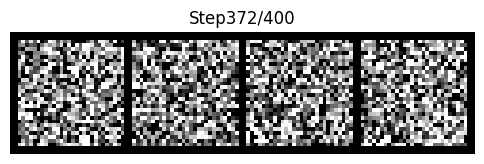

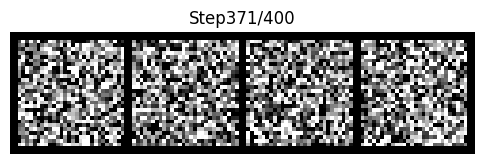

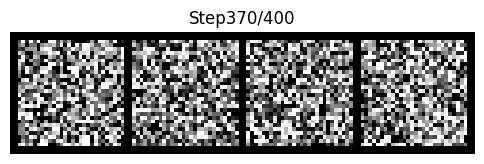

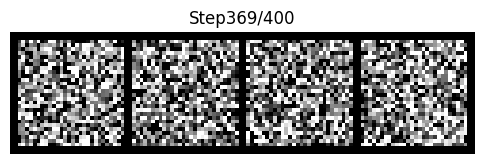

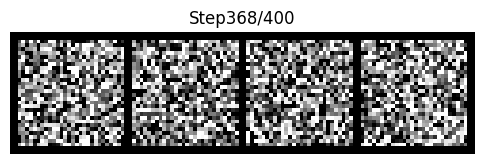

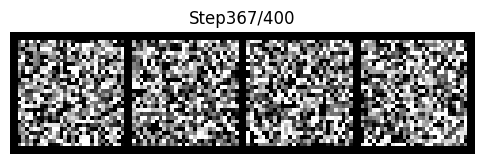

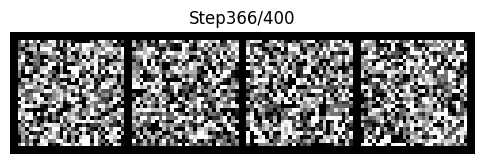

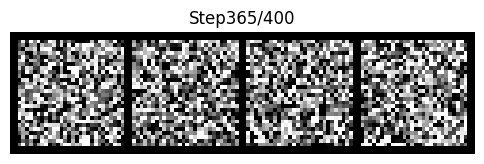

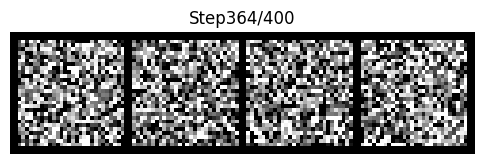

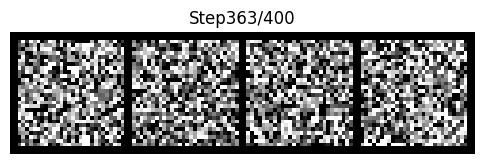

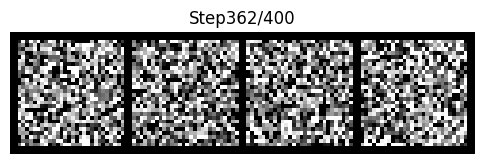

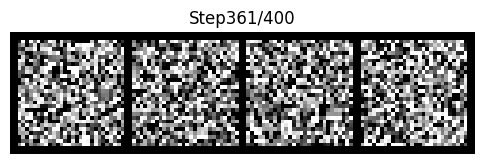

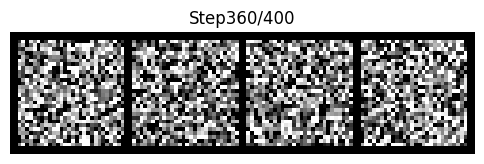

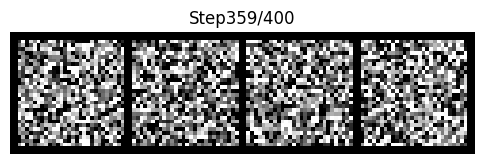

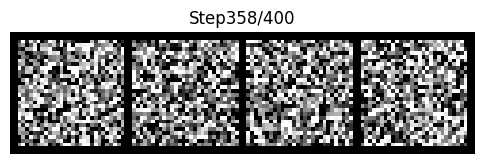

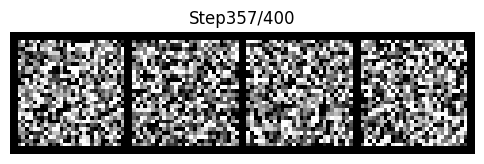

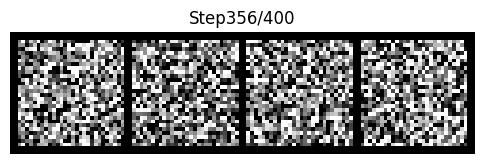

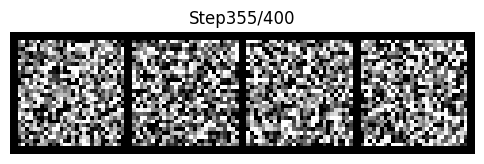

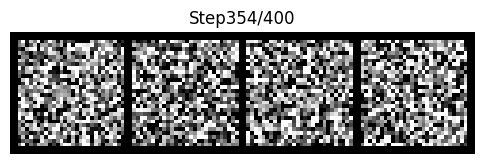

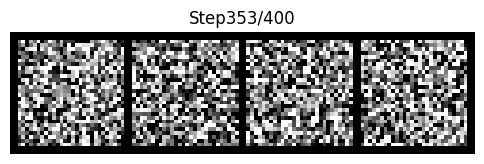

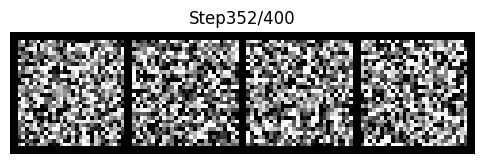

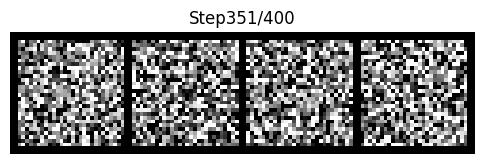

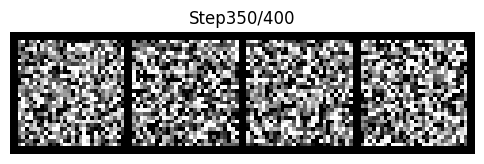

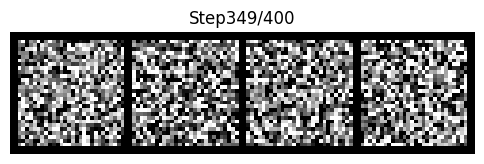

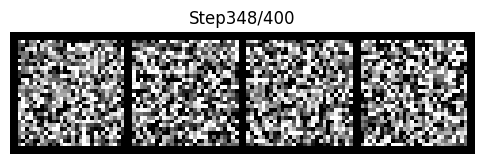

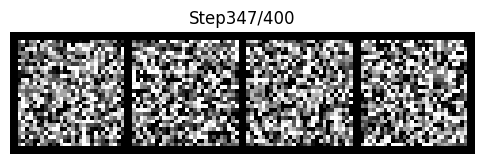

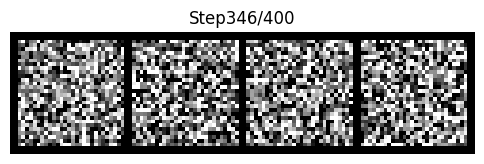

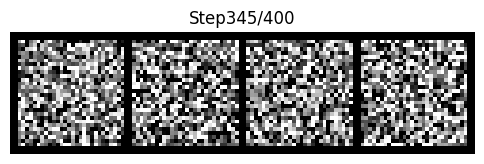

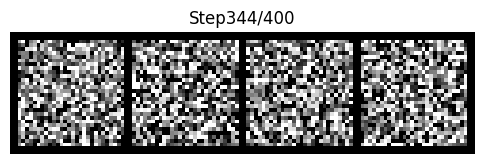

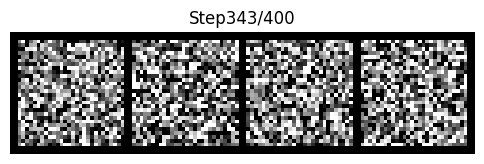

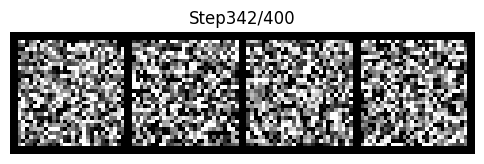

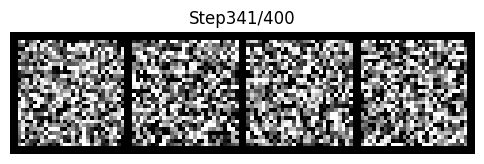

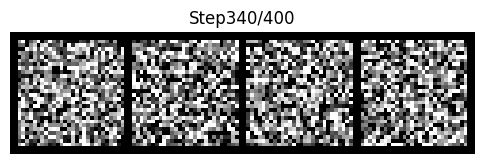

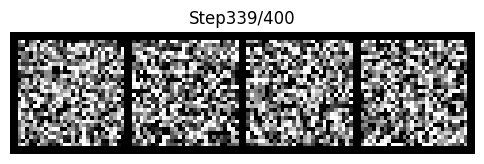

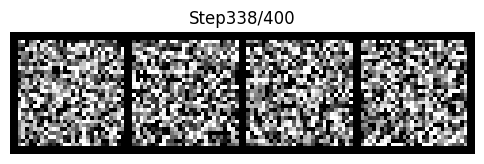

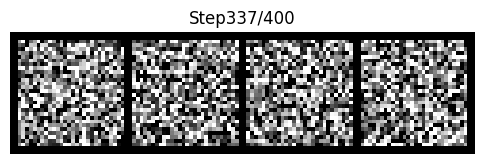

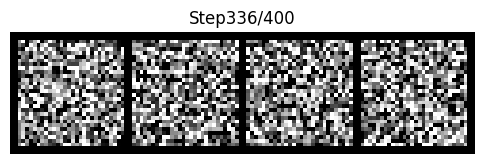

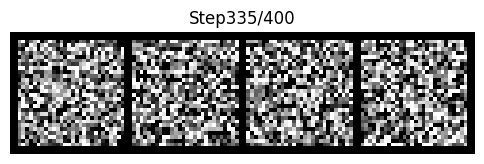

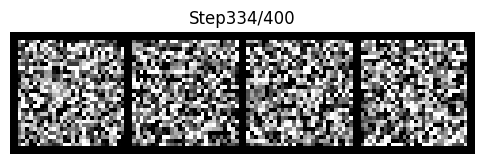

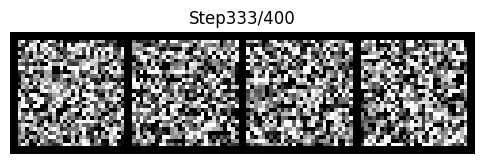

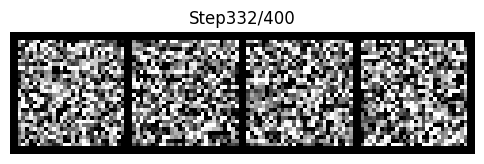

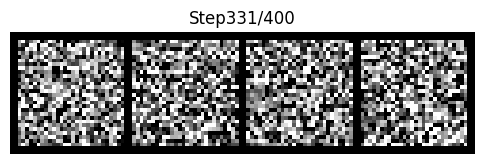

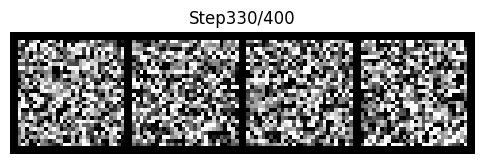

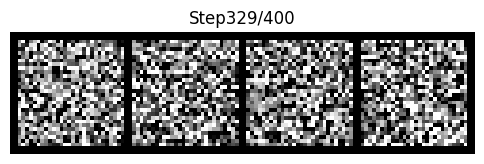

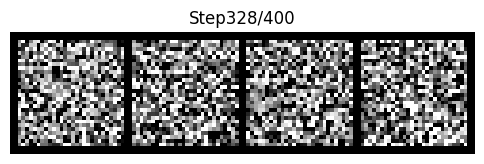

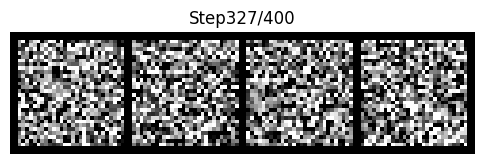

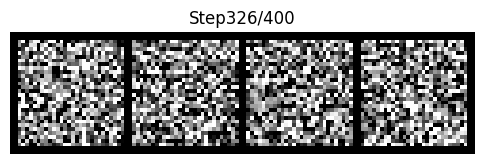

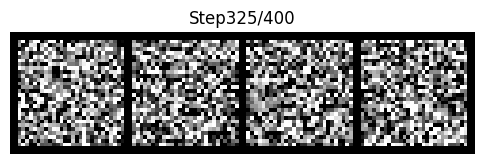

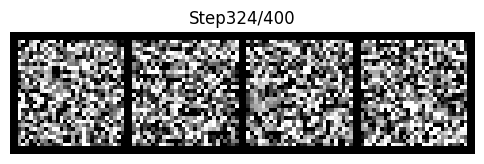

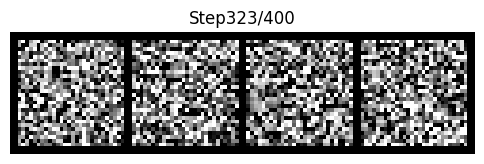

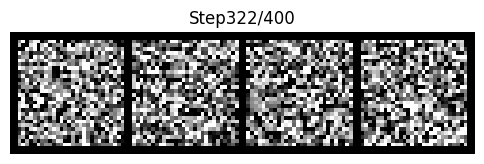

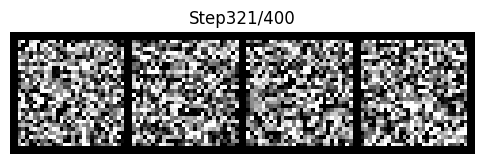

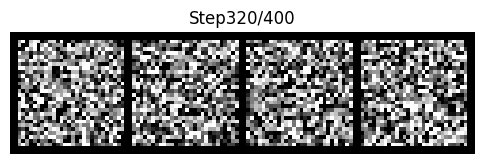

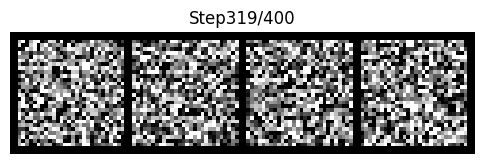

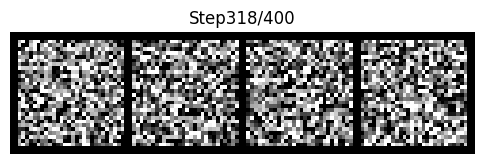

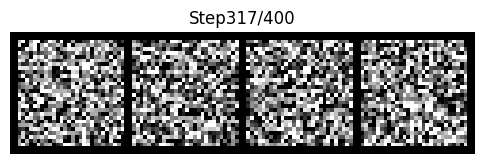

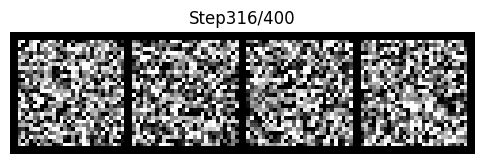

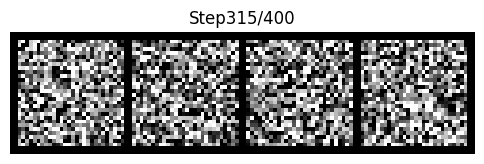

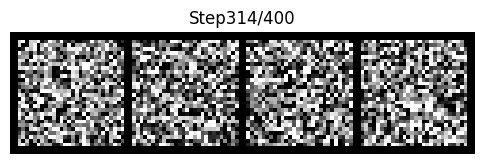

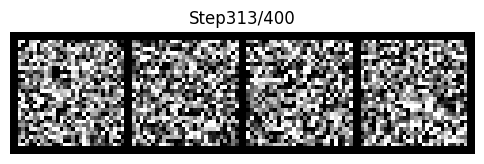

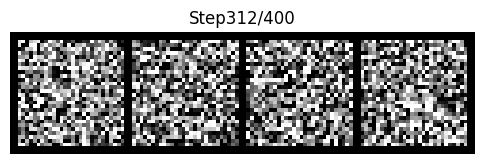

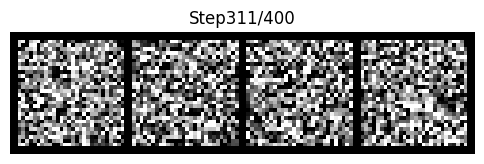

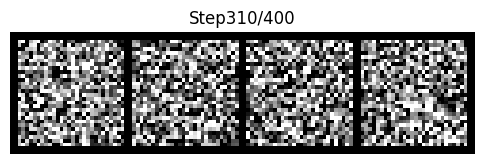

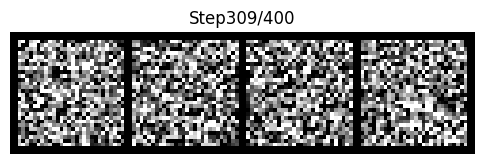

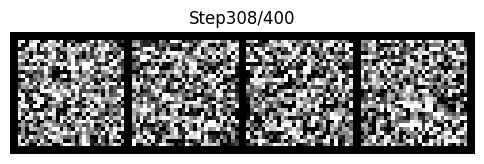

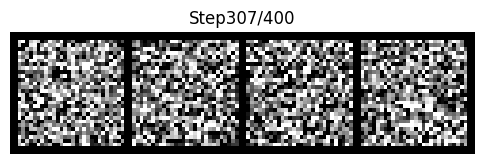

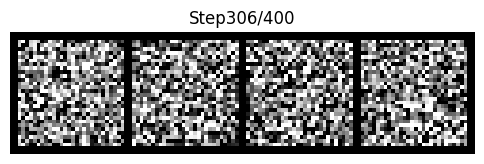

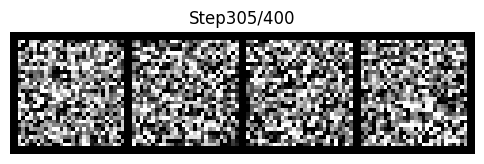

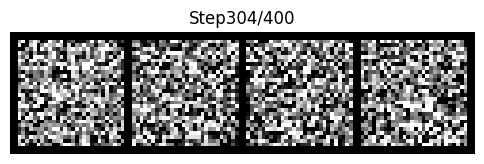

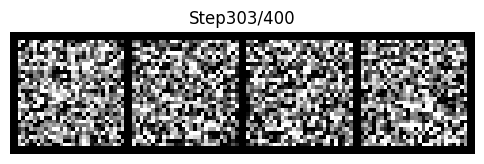

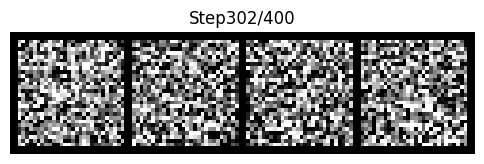

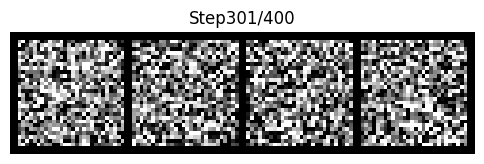

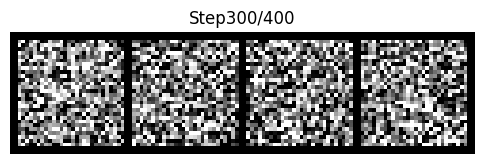

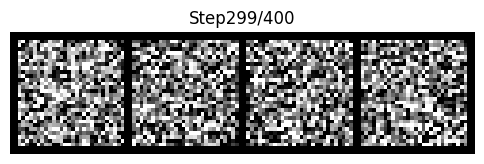

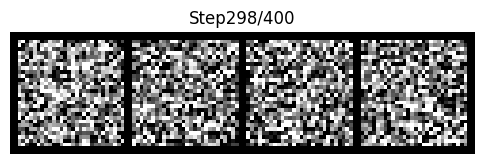

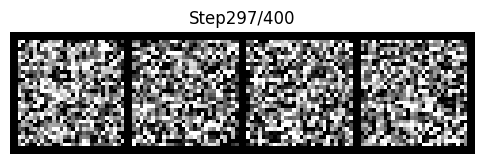

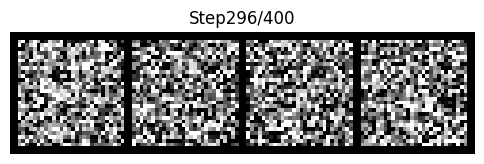

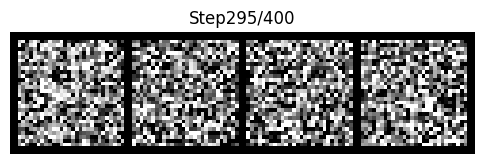

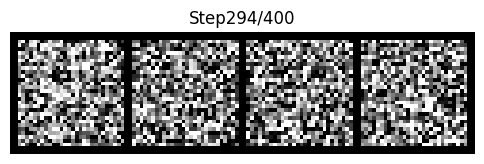

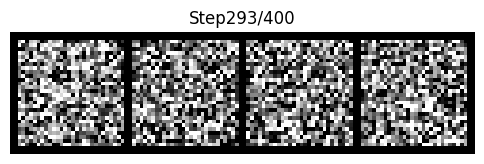

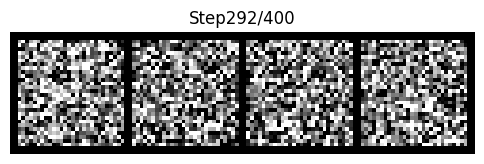

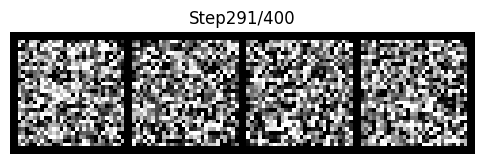

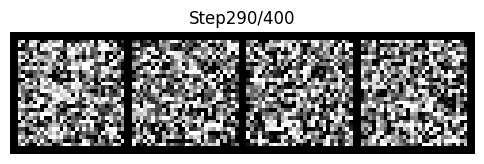

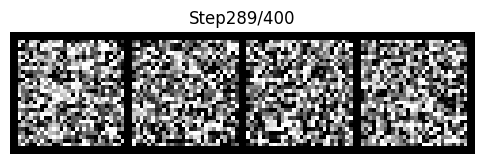

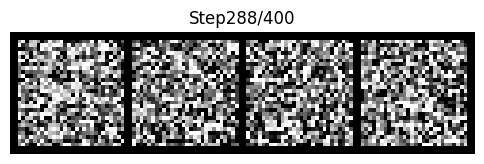

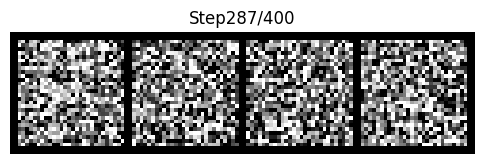

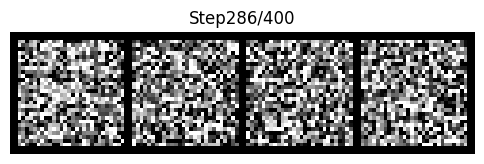

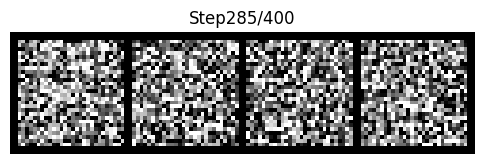

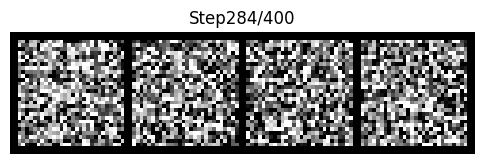

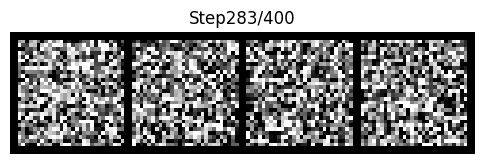

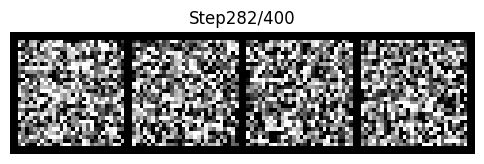

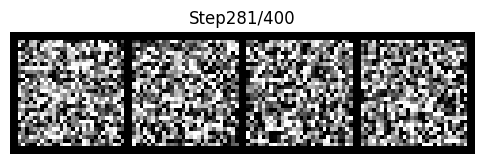

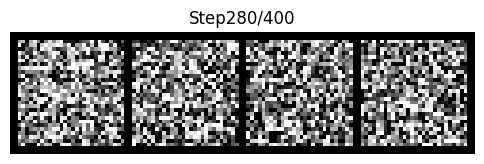

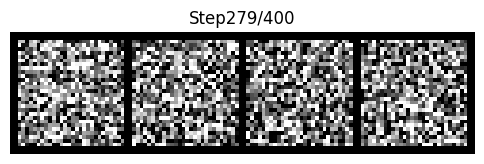

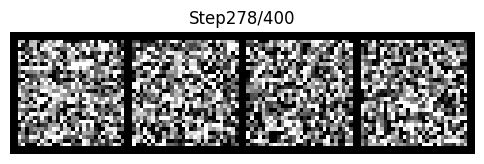

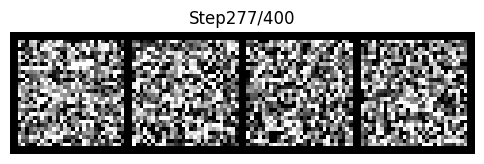

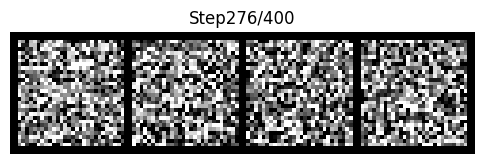

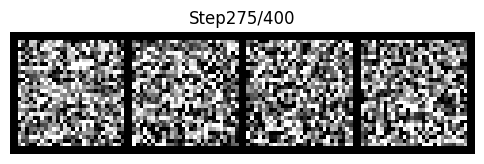

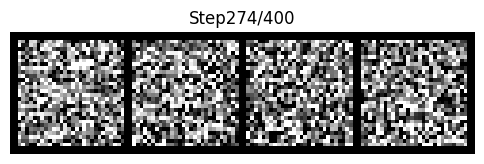

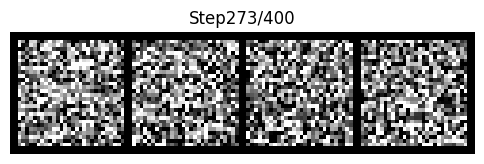

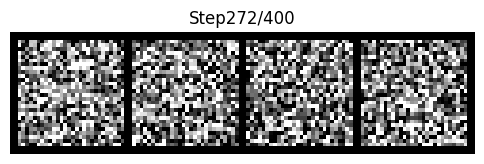

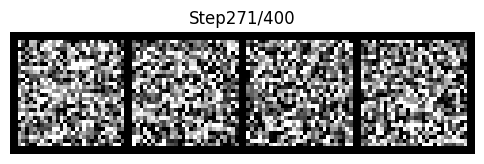

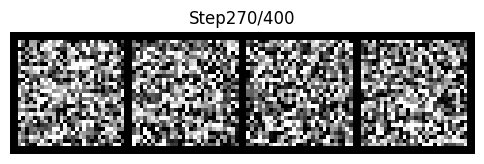

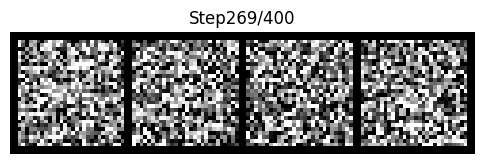

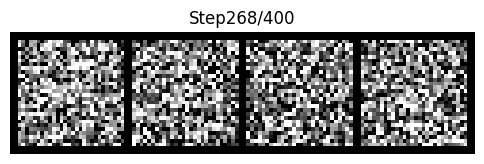

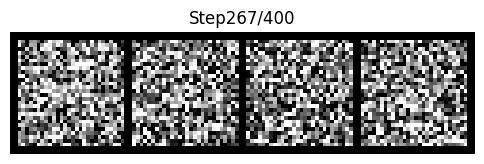

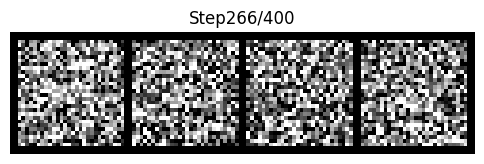

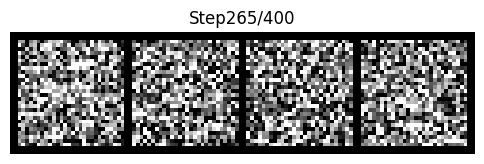

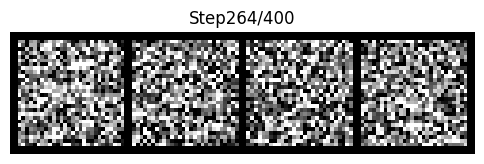

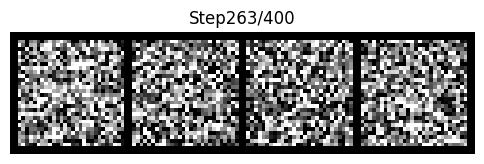

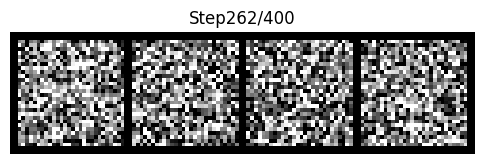

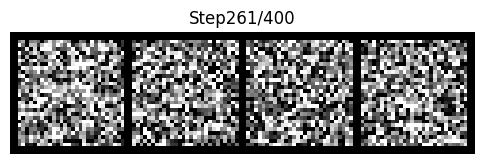

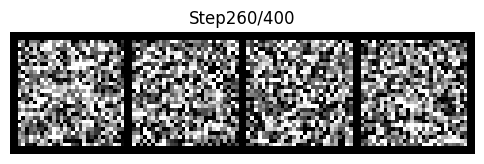

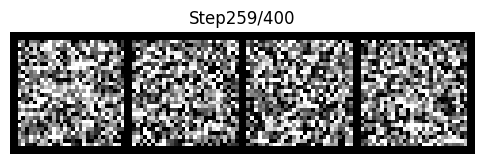

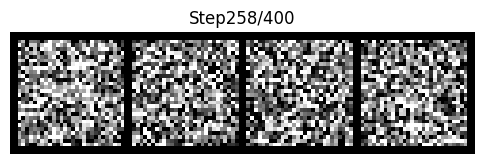

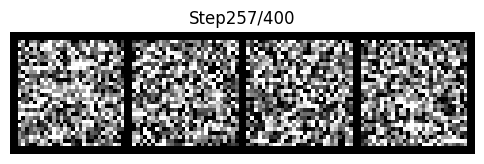

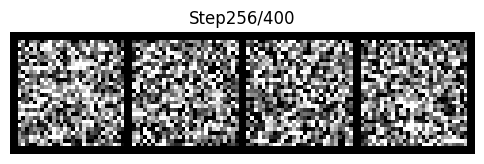

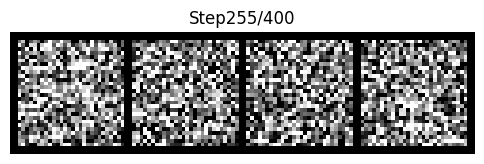

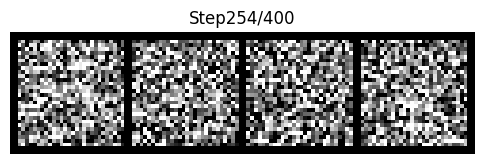

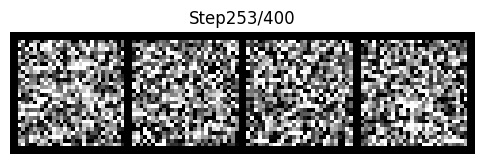

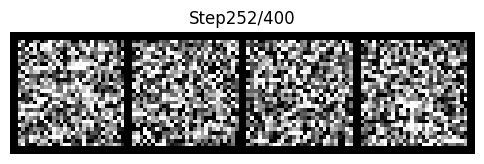

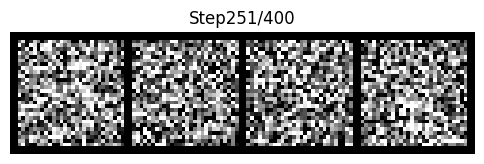

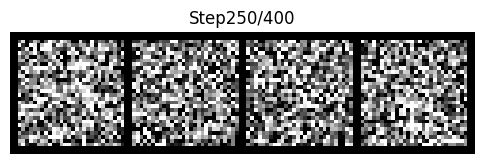

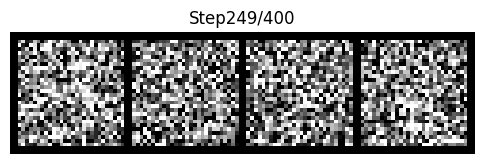

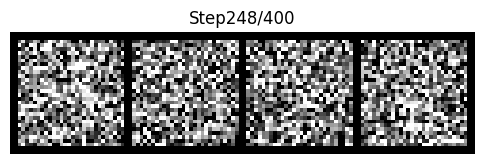

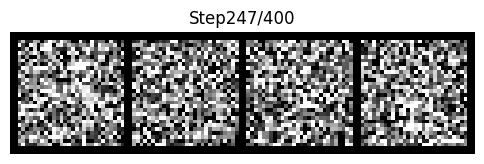

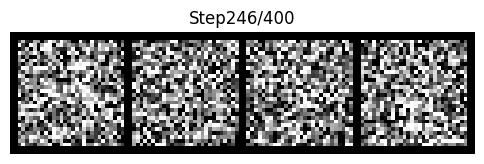

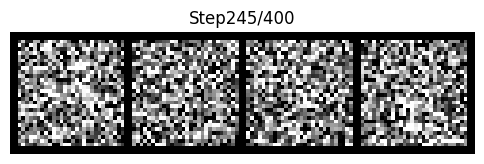

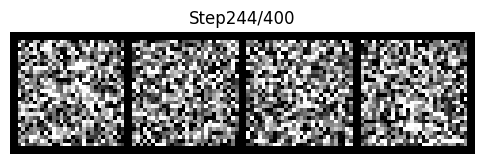

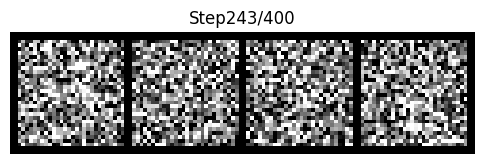

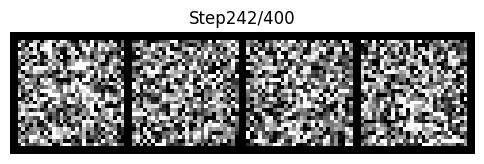

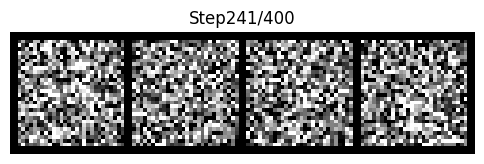

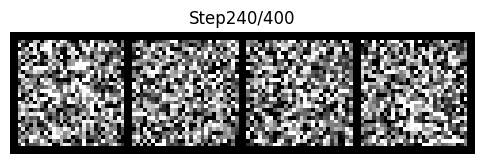

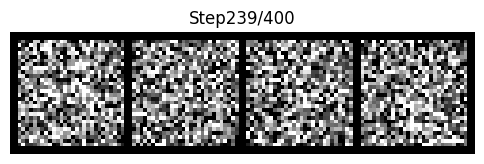

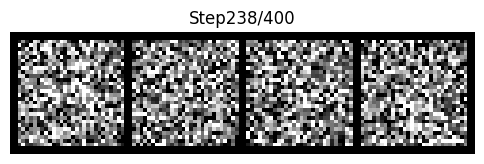

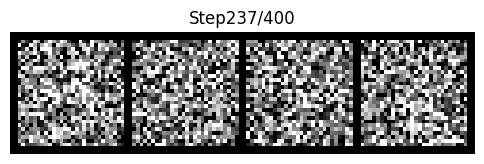

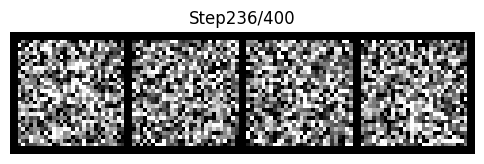

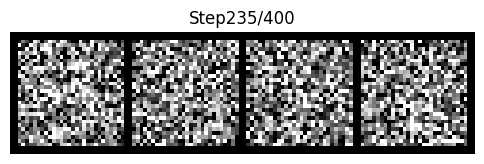

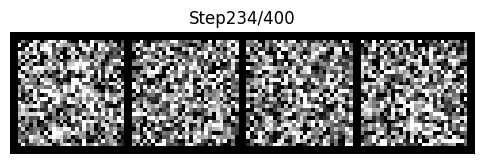

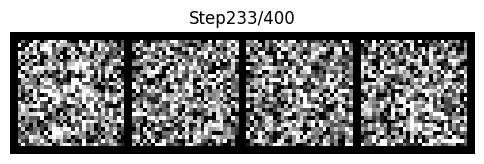

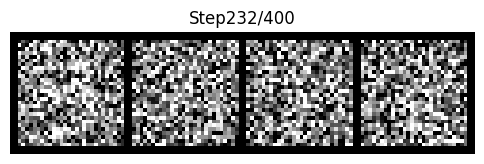

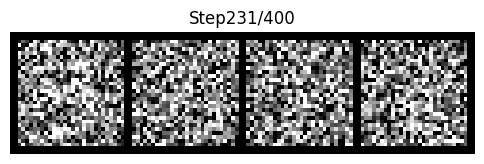

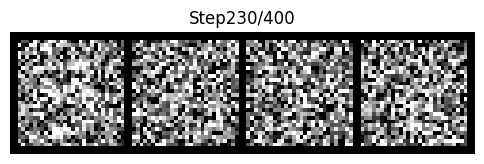

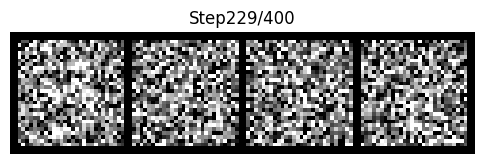

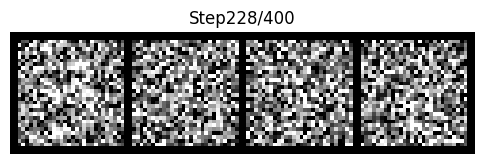

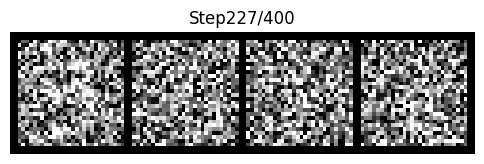

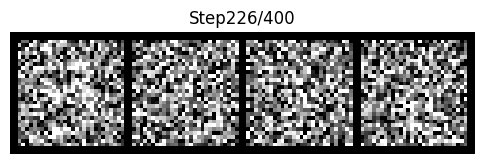

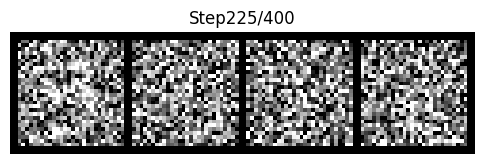

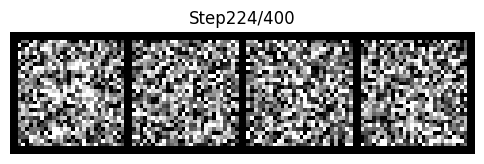

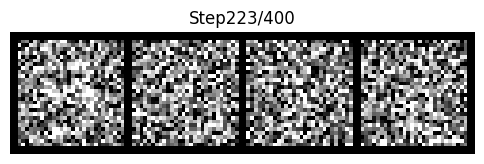

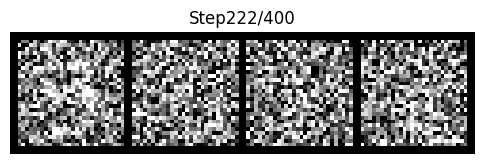

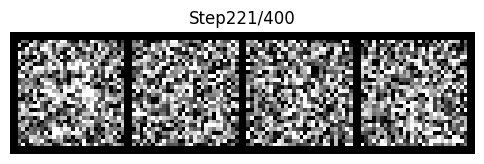

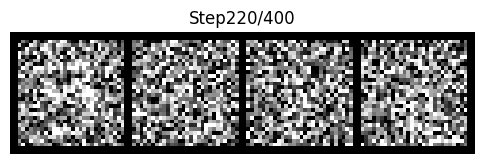

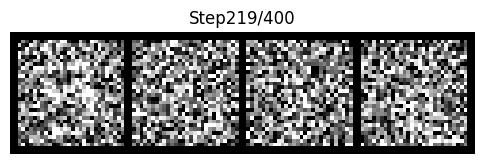

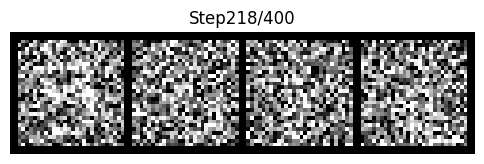

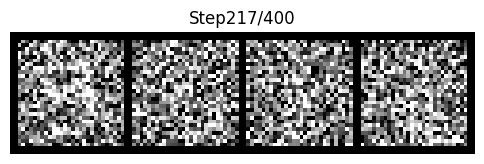

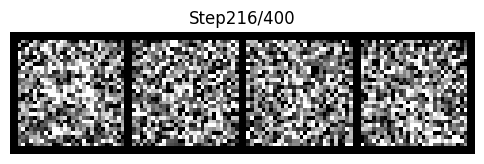

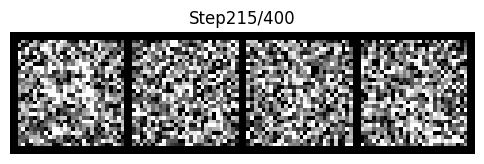

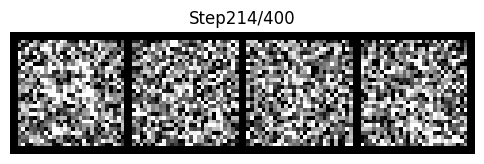

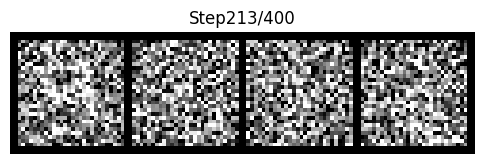

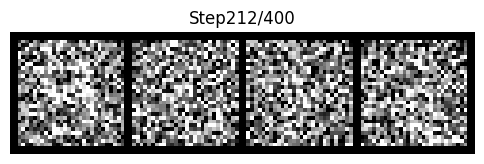

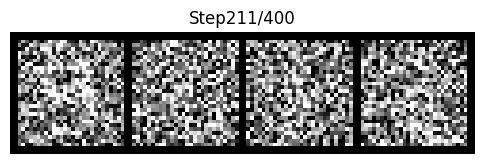

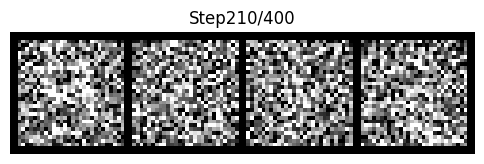

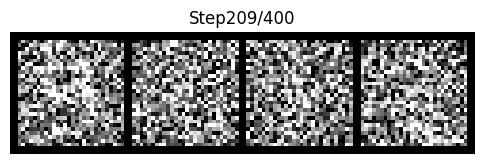

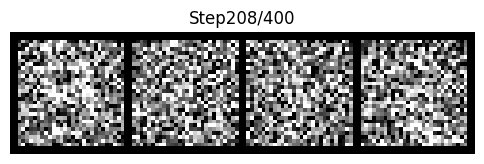

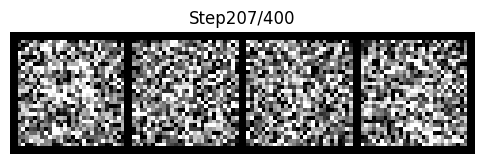

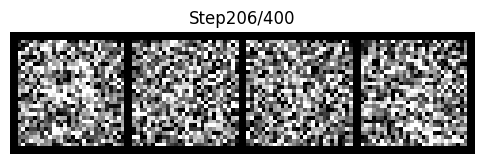

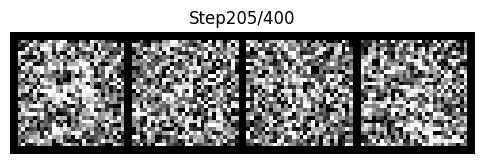

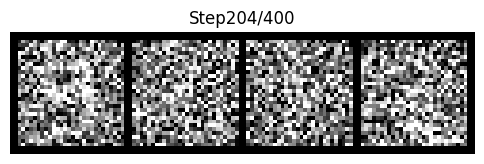

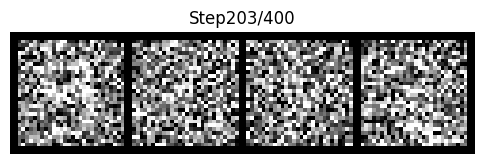

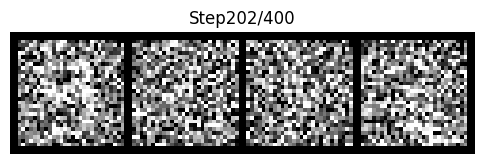

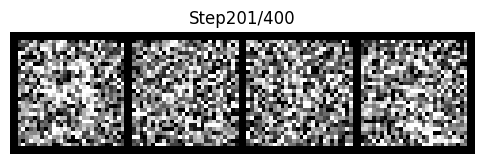

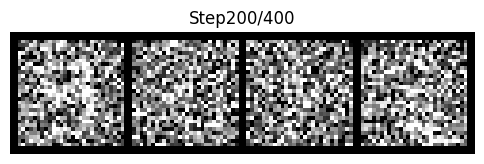

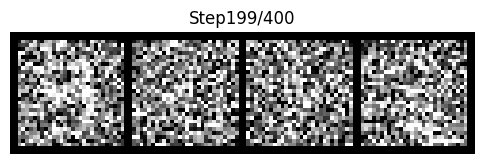

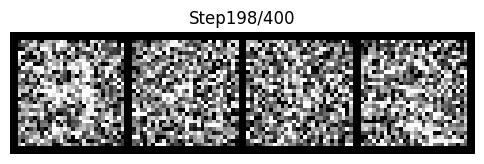

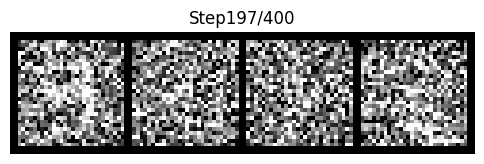

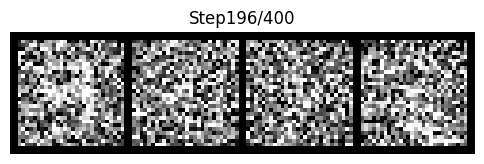

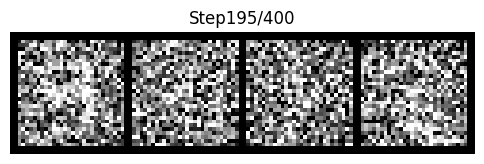

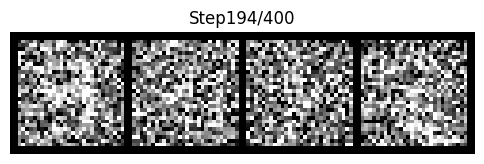

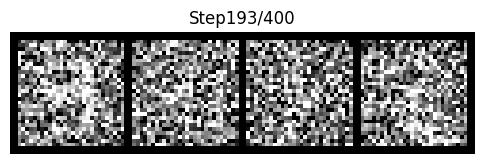

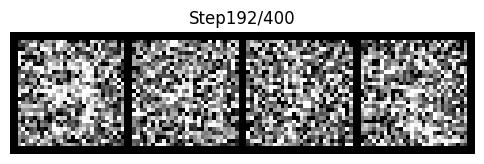

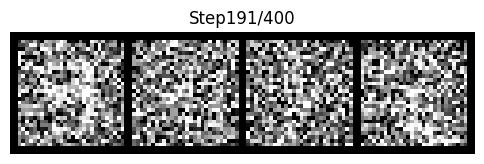

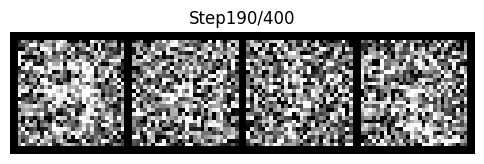

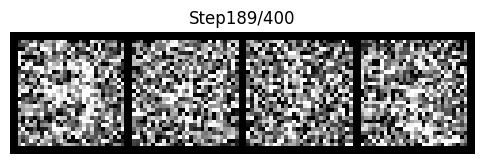

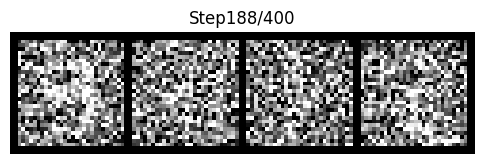

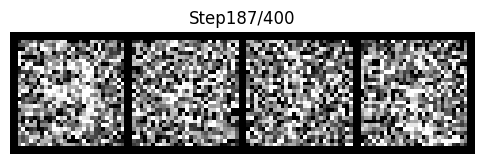

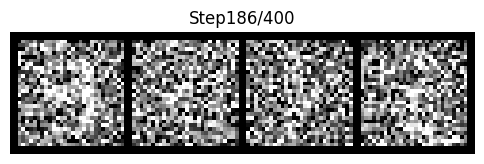

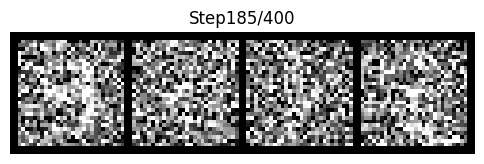

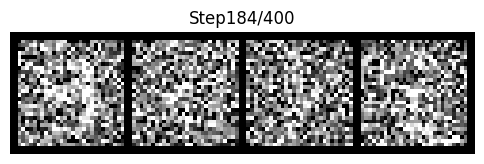

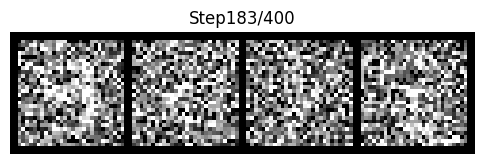

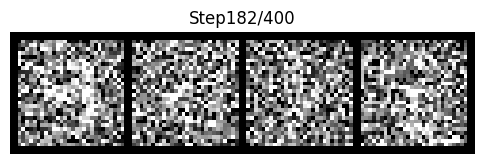

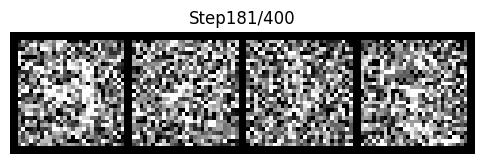

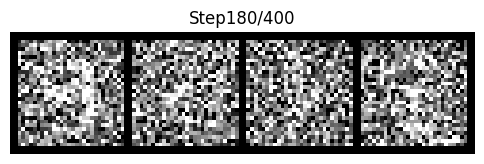

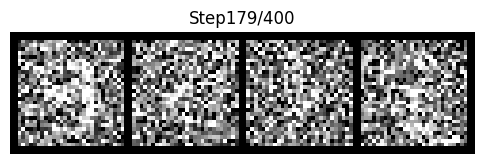

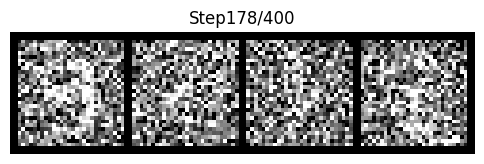

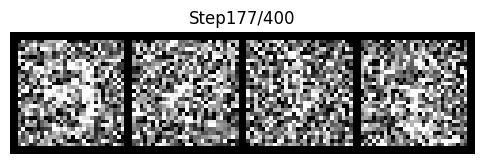

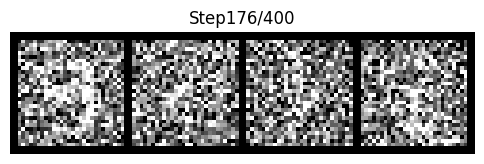

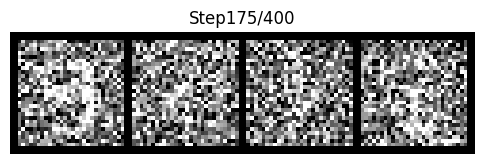

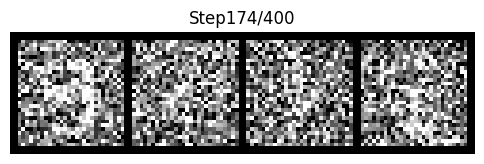

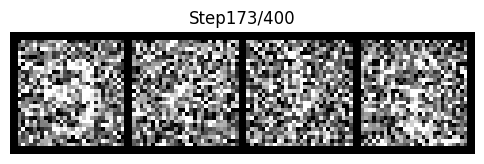

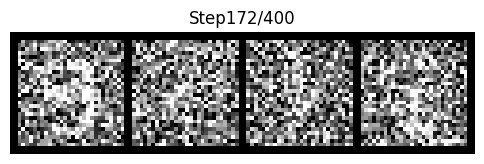

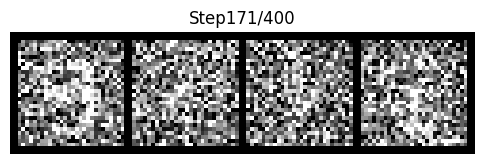

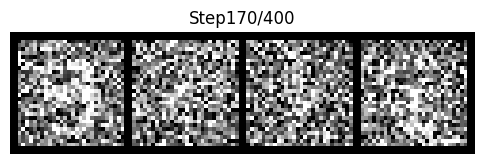

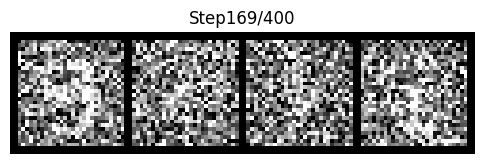

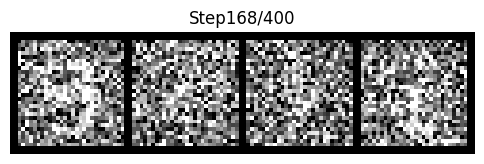

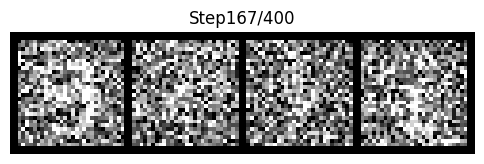

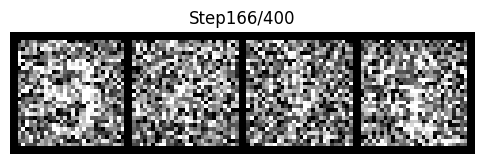

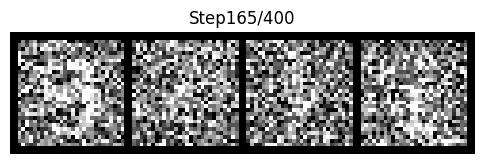

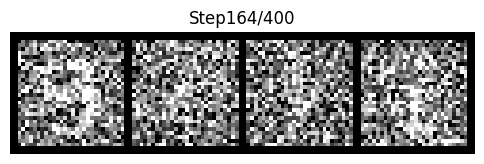

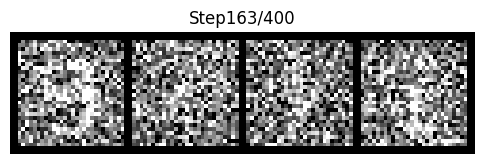

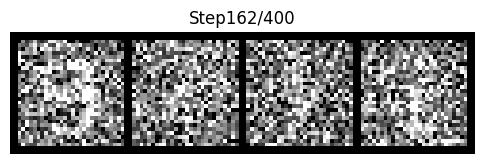

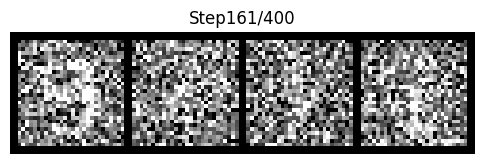

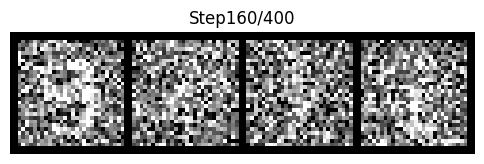

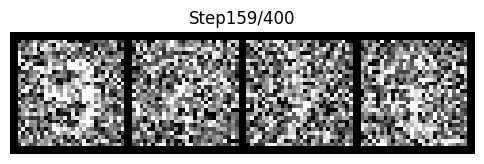

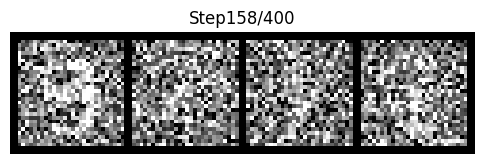

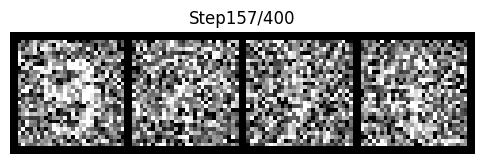

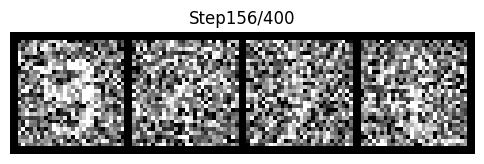

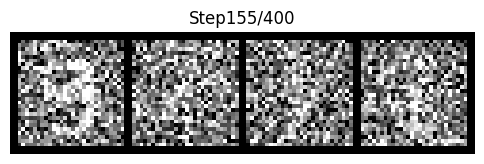

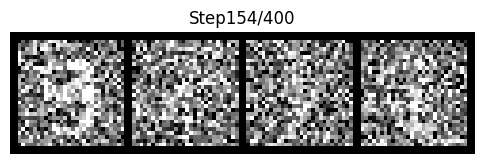

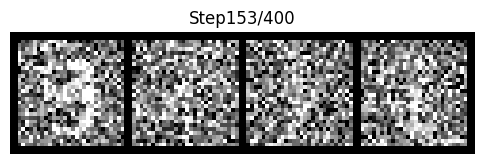

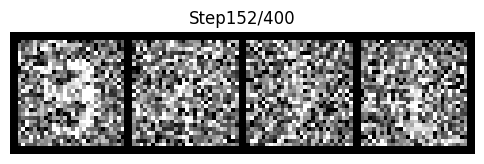

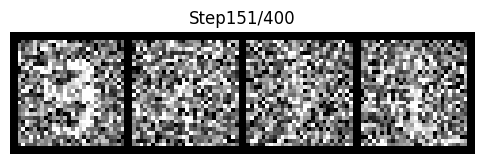

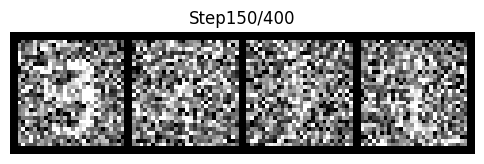

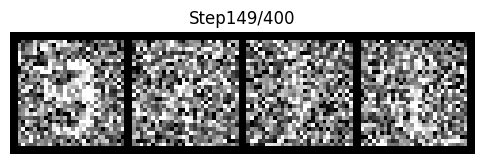

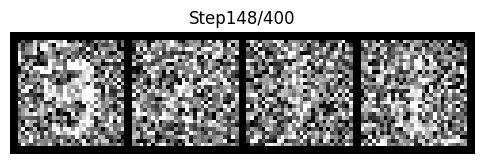

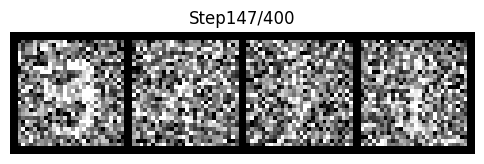

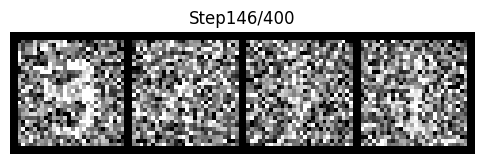

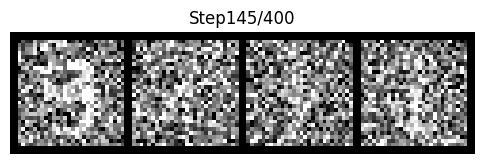

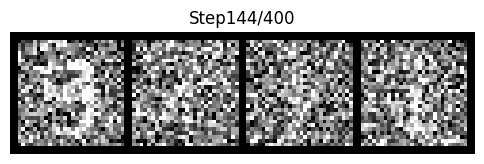

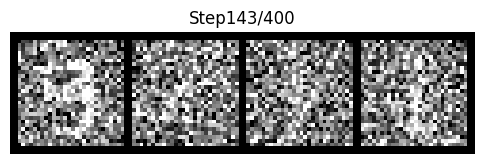

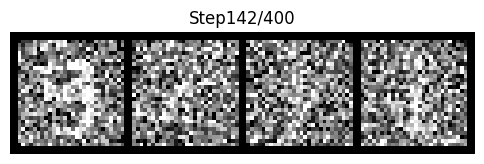

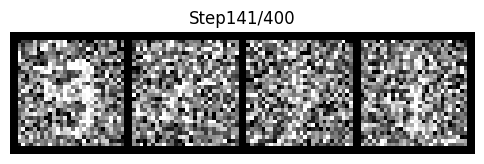

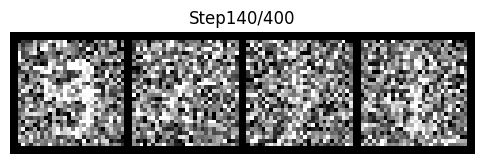

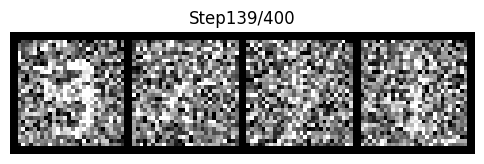

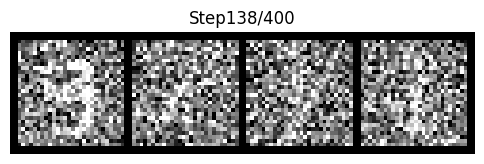

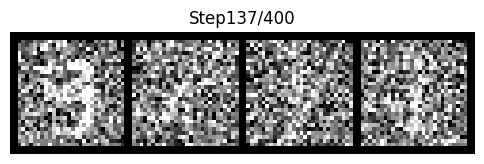

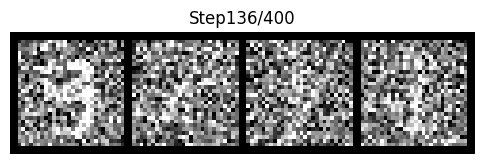

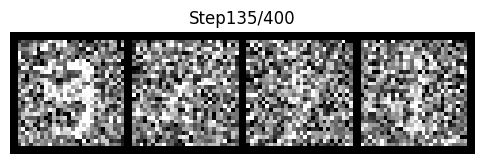

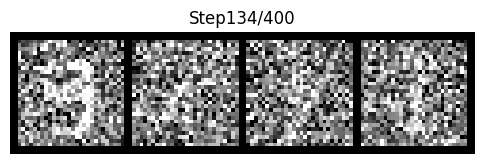

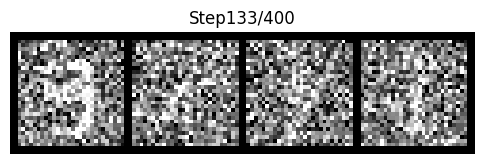

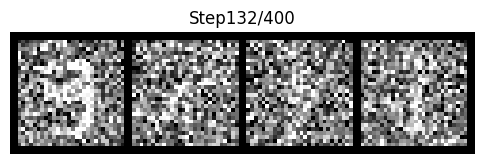

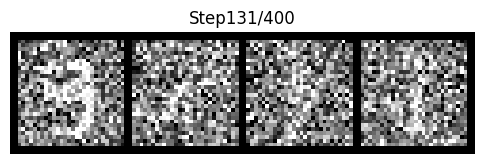

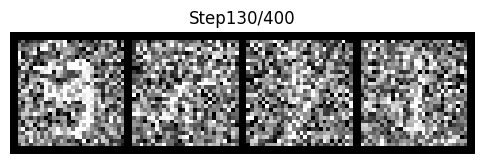

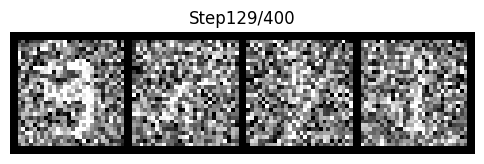

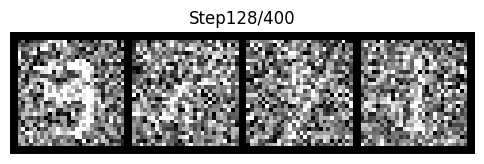

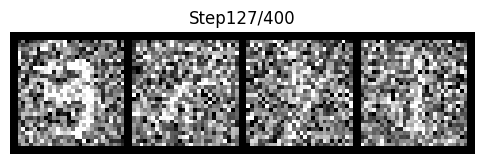

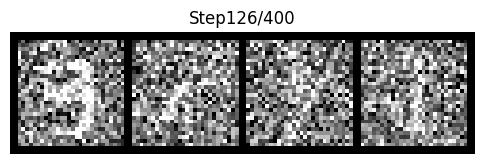

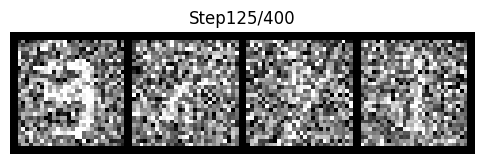

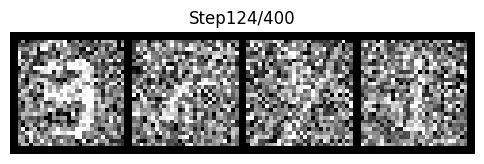

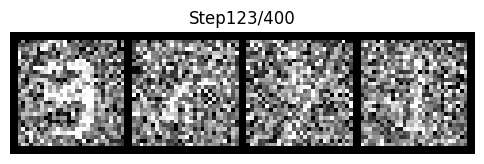

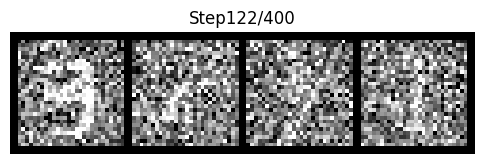

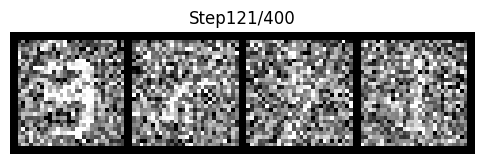

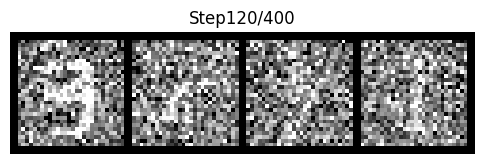

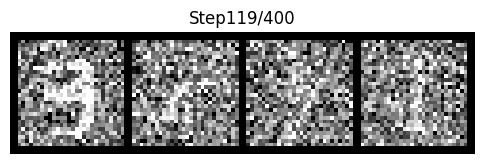

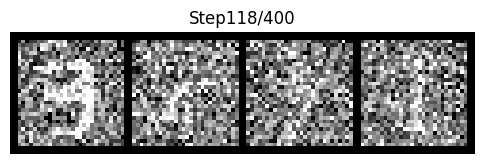

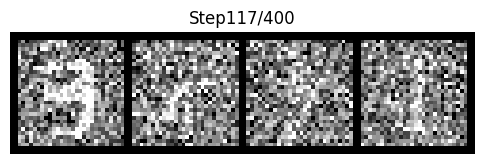

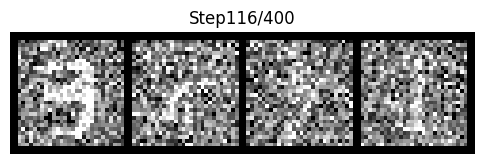

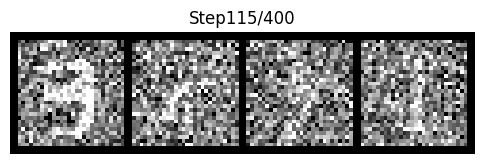

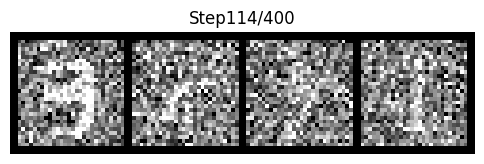

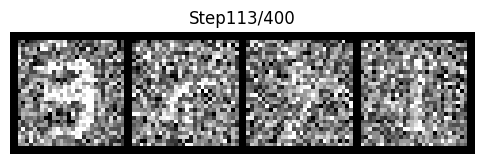

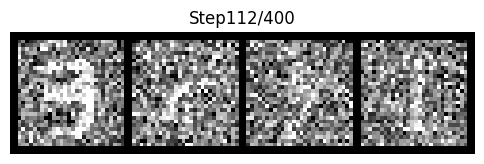

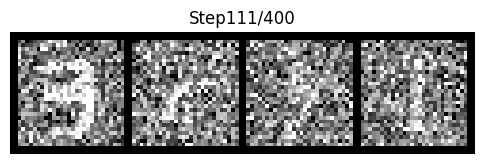

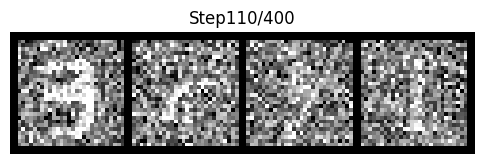

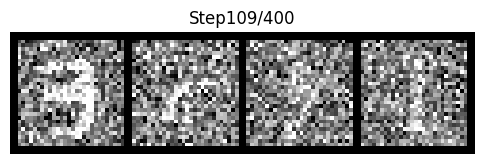

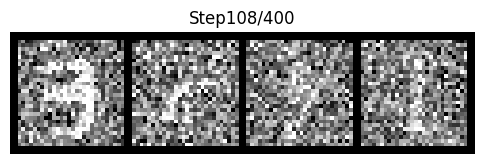

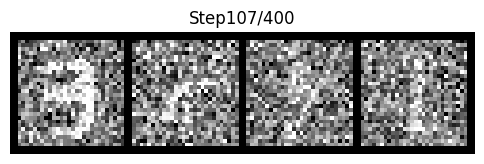

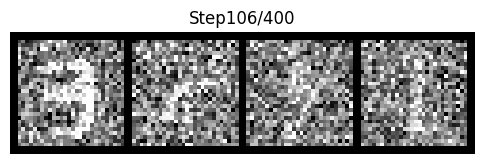

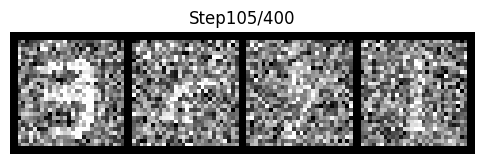

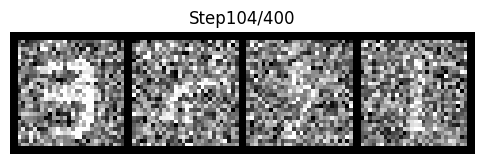

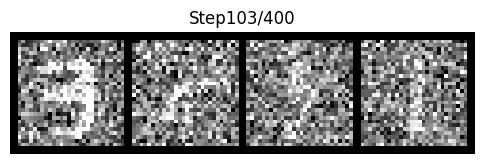

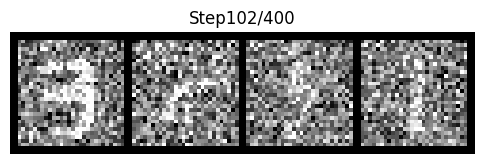

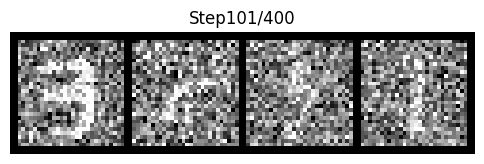

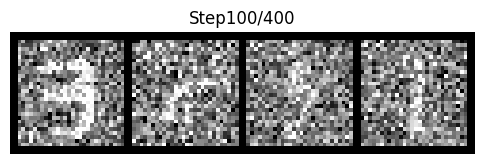

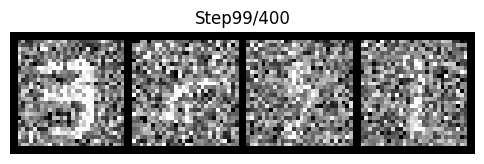

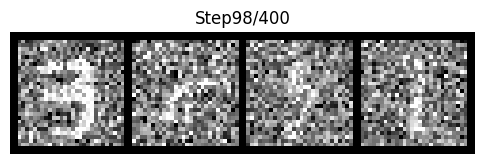

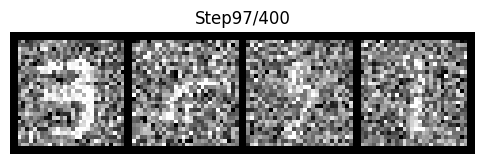

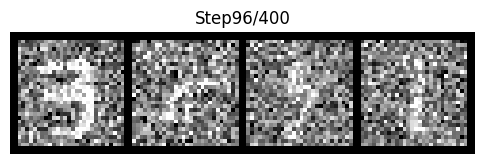

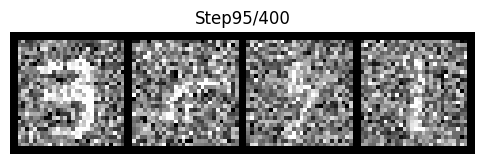

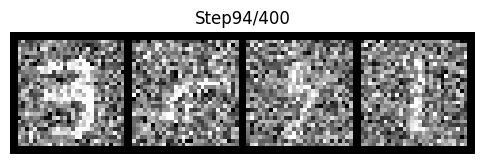

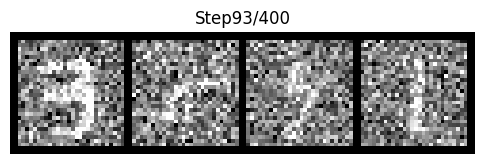

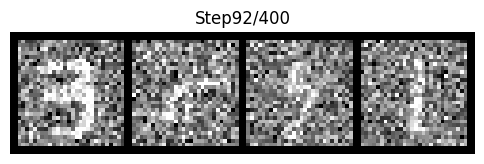

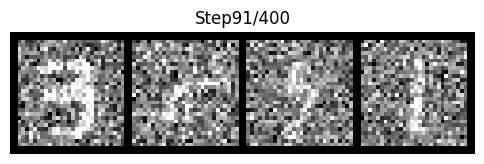

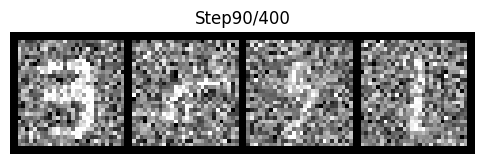

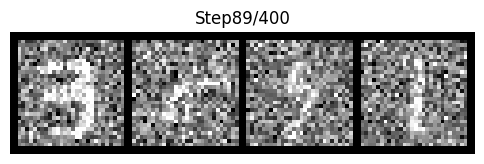

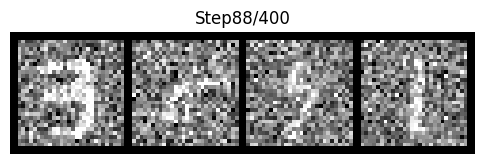

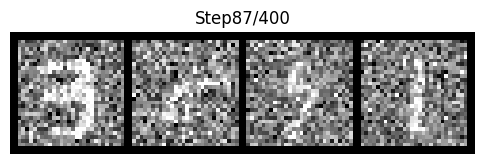

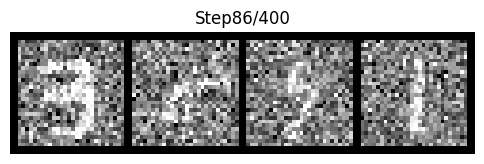

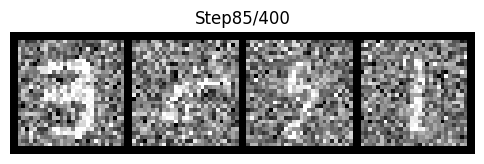

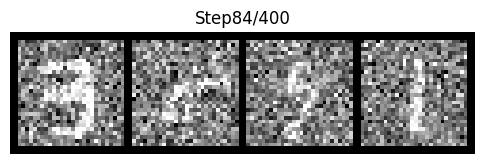

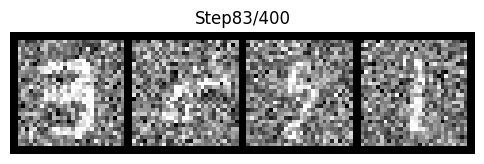

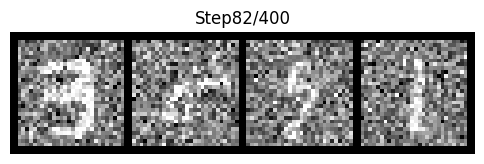

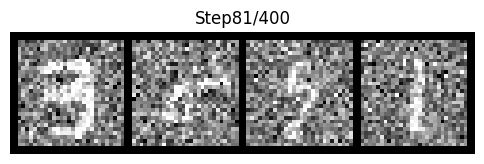

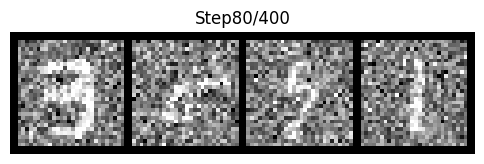

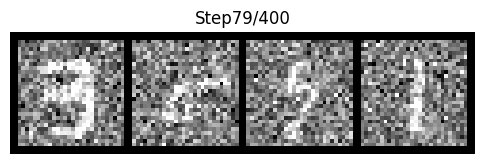

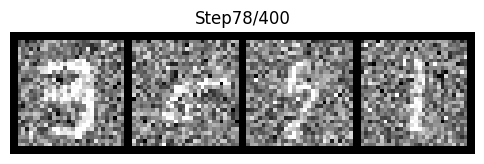

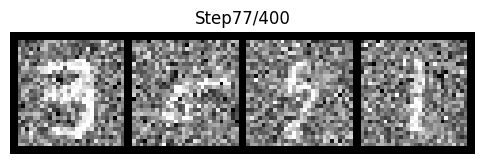

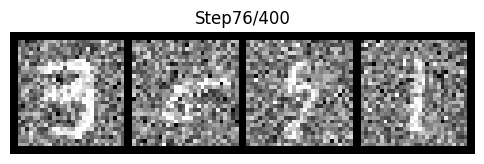

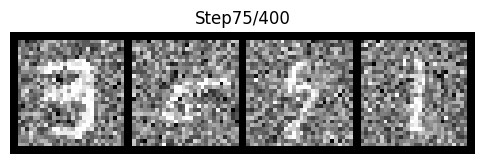

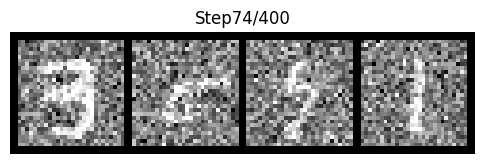

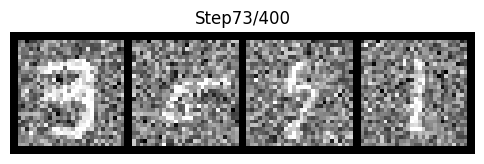

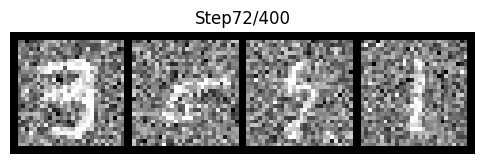

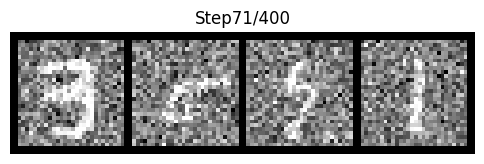

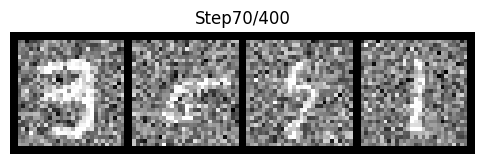

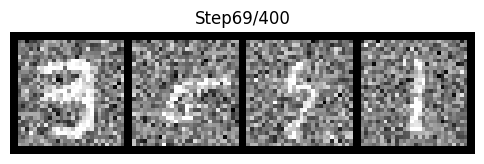

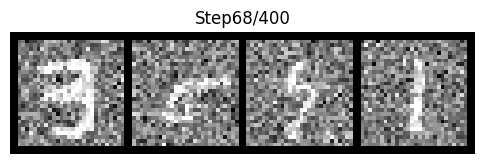

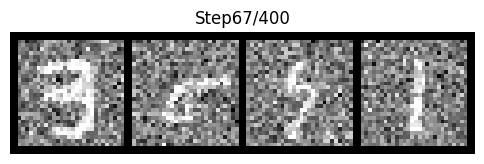

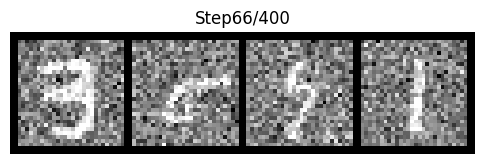

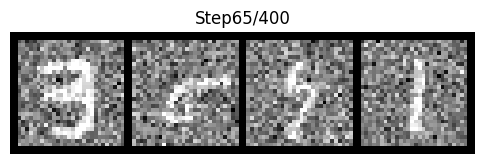

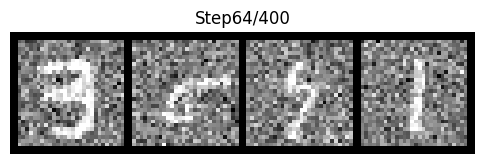

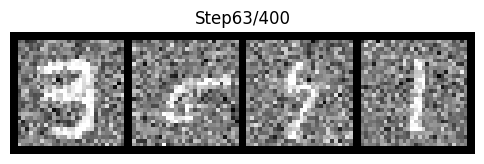

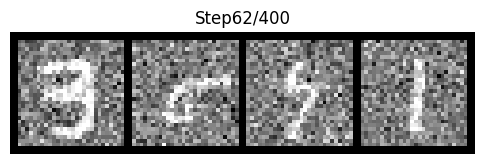

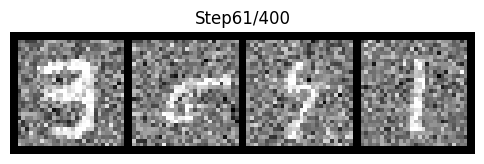

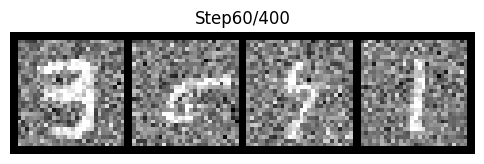

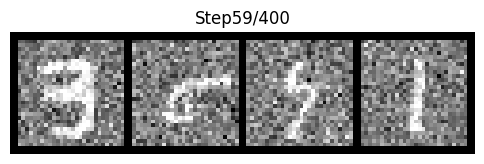

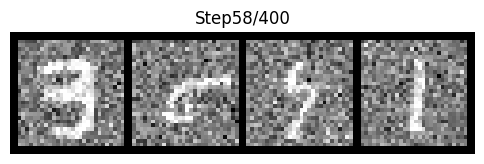

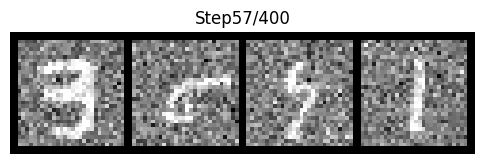

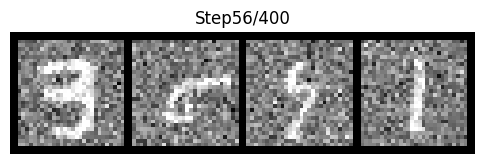

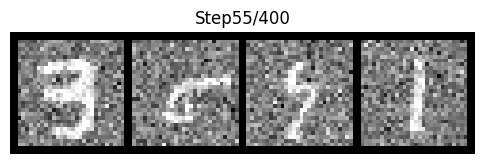

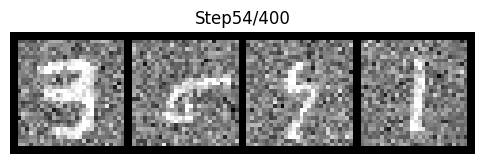

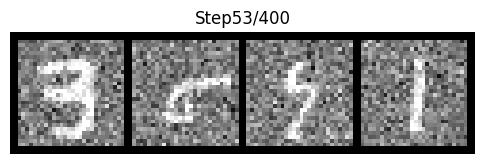

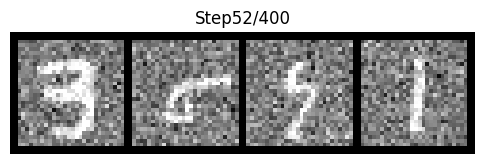

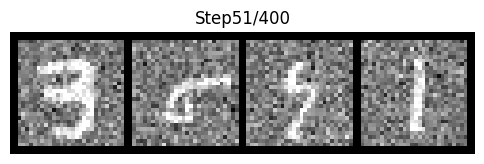

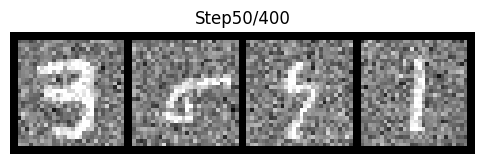

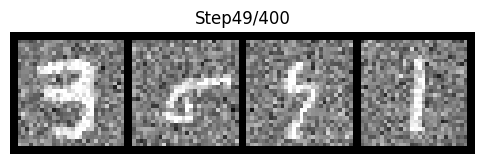

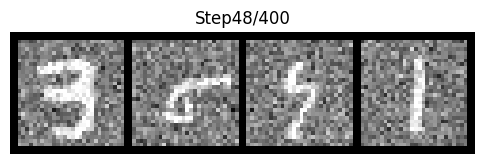

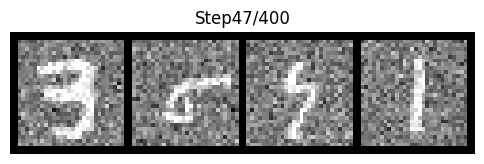

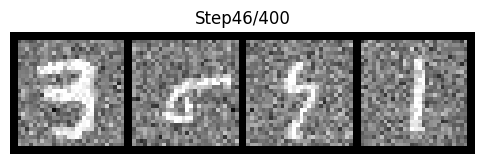

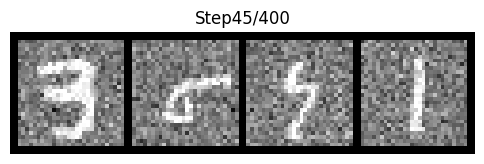

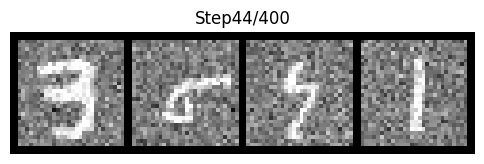

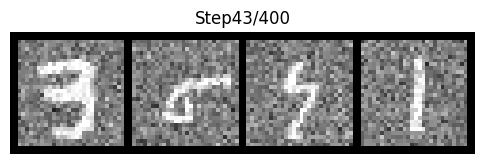

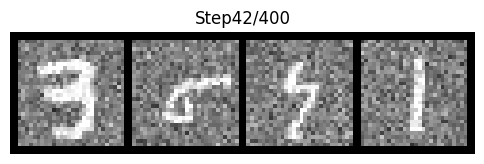

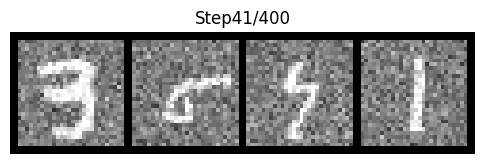

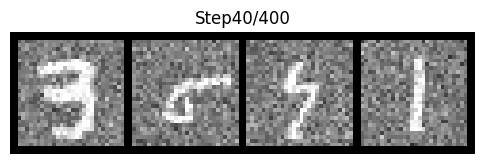

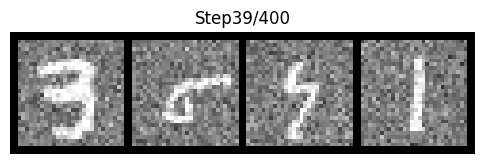

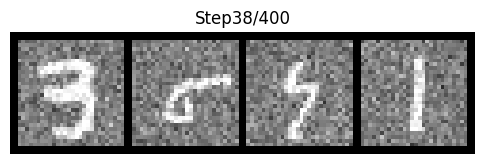

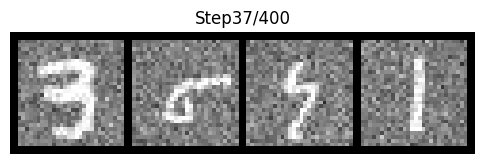

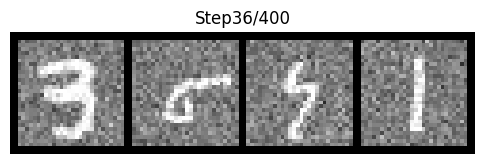

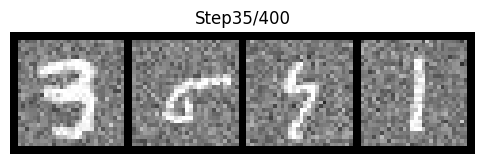

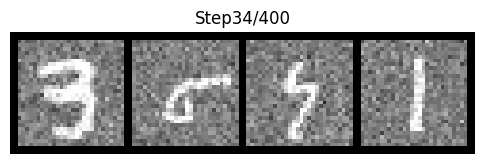

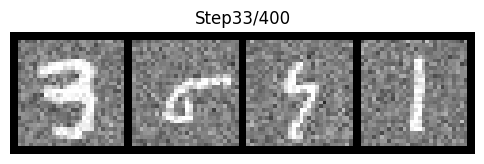

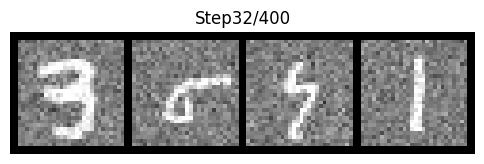

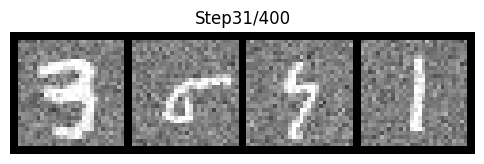

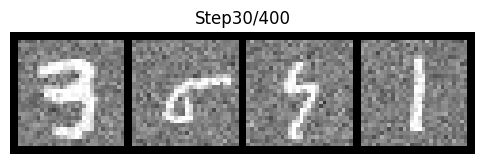

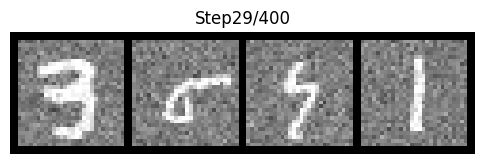

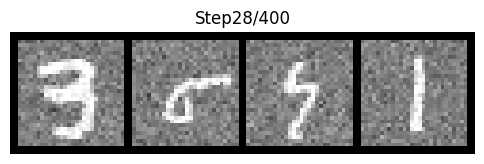

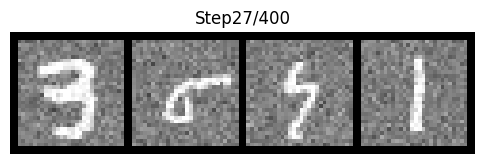

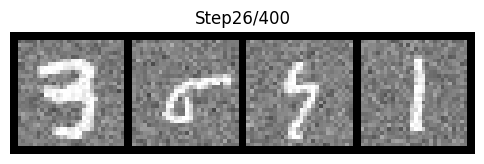

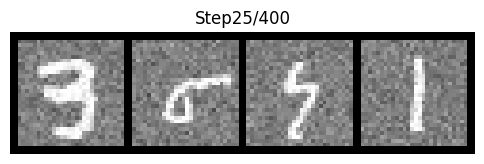

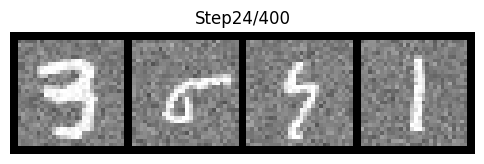

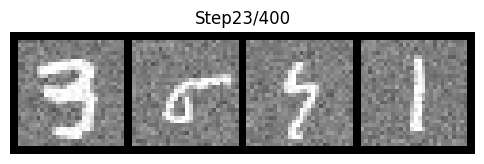

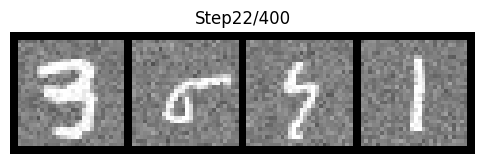

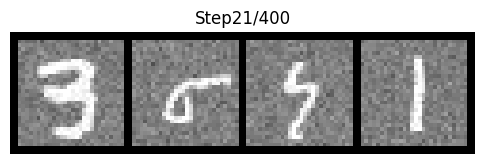

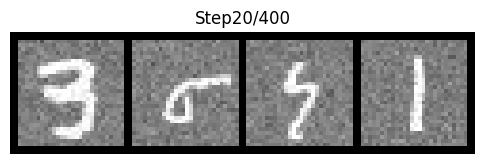

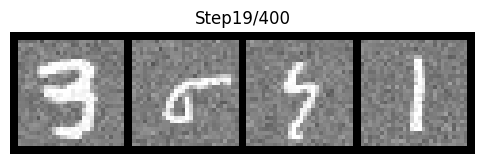

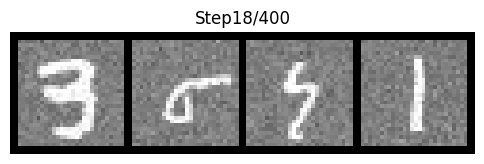

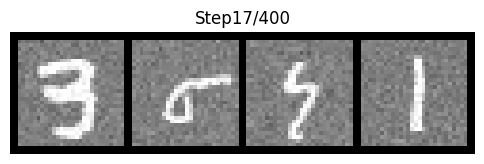

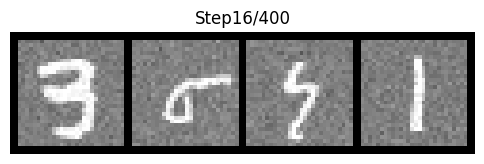

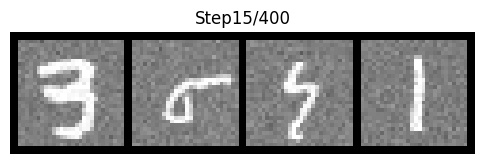

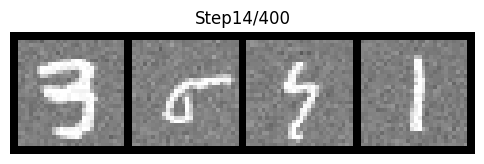

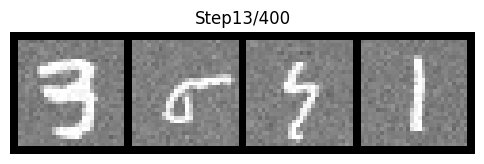

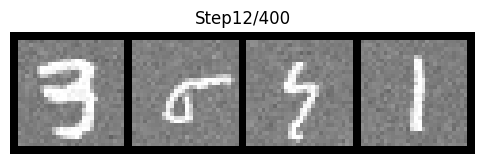

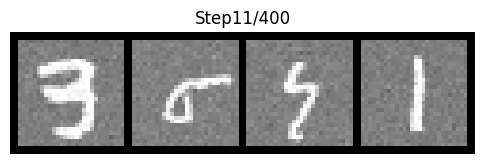

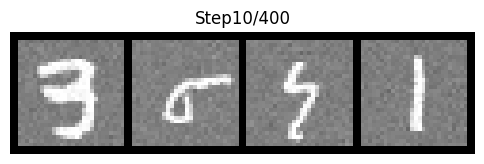

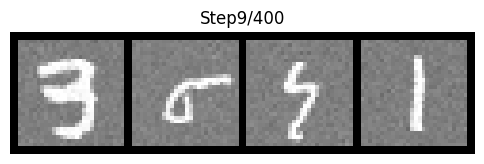

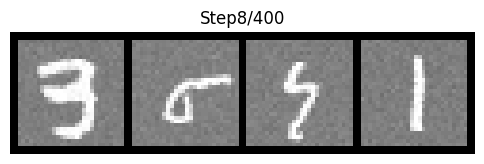

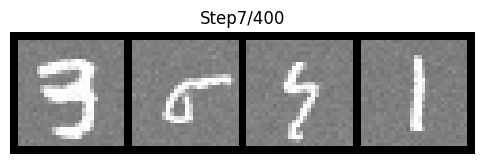

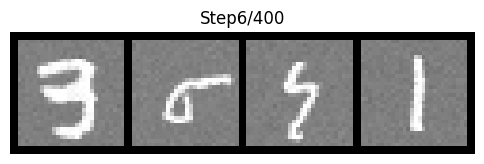

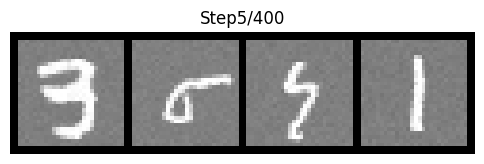

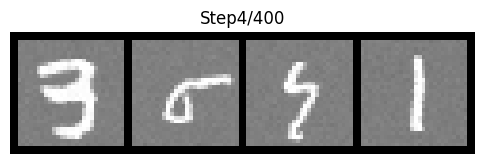

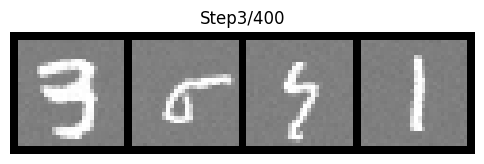

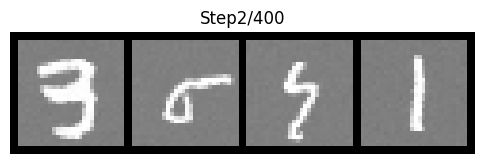

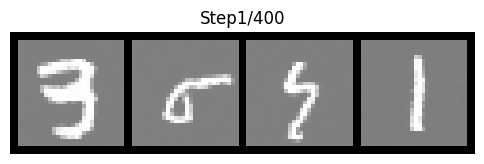

In [8]:
# plot the reverse process

#get image size

sample_idx=torch.randint(len(ds),(1,)).item()
img,label=ds[sample_idx]
img_shape=img.shape

samples_of_steps=sampling_and_trace(model=model,img_shape=img_shape,n=sample_batch_size)

for step, imgs_of_step in enumerate(samples_of_steps):
    plt.figure(figsize=(6,6))
    plt.title(f'Step{T-step}/{T}')
    show_step(imgs_of_step)
   # plt.pause(0.1)
   # plt.close()





